# 📘 Machine Learning Notes
### A Complete University-Style Guide with Theory, Code, Visuals & Projects

**Author:** ML Notes Project &nbsp;|&nbsp; **Language:** Python 🐍 &nbsp;|&nbsp; **Level:** Beginner → Advanced

---

> 🎯 This notebook is a self-contained Machine Learning textbook — explanations in simple English, real-life examples, interview questions, code, visuals, and mini-projects.

---


## 📑 Table of Contents

1. [Introduction to Machine Learning](#ch1)
2. [Types of Machine Learning](#ch2)
3. [Data Preprocessing](#ch3)
4. [Train-Test Split](#ch4)
5. [Linear Regression](#ch5)
6. [Logistic Regression](#ch6)
7. [K-Nearest Neighbors (KNN)](#ch7)
8. [Decision Trees](#ch8)
9. [Random Forest](#ch9)
10. [Support Vector Machine (SVM)](#ch10)
11. [Naive Bayes](#ch11)
12. [Clustering (K-Means, Hierarchical)](#ch12)
13. [Principal Component Analysis (PCA)](#ch13)
14. [Neural Networks](#ch14)
15. [Deep Learning Basics](#ch15)
16. [Model Evaluation Metrics](#ch16)
17. [Overfitting and Underfitting](#ch17)
18. [Cross Validation](#ch18)
19. [Hyperparameter Tuning](#ch19)
20. [End-to-End ML Project](#ch20)
21. [Mini Projects](#ch21)
22. [Revision Notes](#ch22)
23. [Cheat Sheet](#ch23)
24. [Formula Sheet](#ch24)
25. [Interview Preparation](#ch25)
26. [100 ML MCQs with Answers](#ch26)

---


## ⚙️ 0. Setup — Imports & Folder Configuration

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              mean_squared_error, mean_absolute_error, r2_score,
                              precision_score, recall_score, f1_score, roc_curve, auc)
from scipy.cluster.hierarchy import dendrogram, linkage

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

# Folder paths (relative to this notebook's location: Machine-Learning-Notes/)
GRAPHS_DIR = "graphs"
DATASETS_DIR = "datasets"
IMAGES_DIR = "images"
PROJECTS_DIR = "projects"
for d in [GRAPHS_DIR, DATASETS_DIR, IMAGES_DIR, PROJECTS_DIR]:
    os.makedirs(d, exist_ok=True)

def save_plot(fig, name):
    """Save a matplotlib figure into the graphs/ folder as PNG."""
    path = os.path.join(GRAPHS_DIR, name)
    fig.savefig(path, bbox_inches="tight")
    print(f"✅ Saved: {path}")

print("✅ Environment ready. All libraries imported successfully!")


✅ Environment ready. All libraries imported successfully!


<a id="ch1"></a>
## 🤖 1. Introduction to Machine Learning
---


### 🧠 Simple Explanation
Machine Learning (ML) is a way of teaching computers to learn from data and experience, instead of writing exact step-by-step instructions. The computer finds patterns in data and uses them to make predictions or decisions.

### 📖 Definition
> Machine Learning is a subfield of Artificial Intelligence that gives systems the ability to automatically learn and improve from experience (data) without being explicitly programmed.

### 🌍 Real-life Examples
- Netflix recommending movies based on what you watched before
- Gmail automatically detecting spam emails
- Face unlock on your phone recognizing your face
- Banks predicting whether a loan applicant will default

### ✅ Advantages
- Automates decision making
- Improves with more data
- Finds hidden patterns humans may miss
- Handles complex, high-dimensional problems

### ❌ Disadvantages
- Needs large amounts of quality data
- Can be a 'black box' (hard to interpret)
- Expensive to train large models
- Prone to bias if data is biased

### 💼 Use Cases
- Fraud detection
- Recommendation systems
- Medical diagnosis
- Self-driving cars
- Chatbots and virtual assistants

### ❓ Important Interview Questions
1. What is Machine Learning and how is it different from traditional programming?
2. What is the difference between AI, ML, and Deep Learning?
3. What are the main steps in a typical ML pipeline?
4. Why is data quality important in ML?

---


✅ Saved: graphs/01_traditional_vs_ml.png


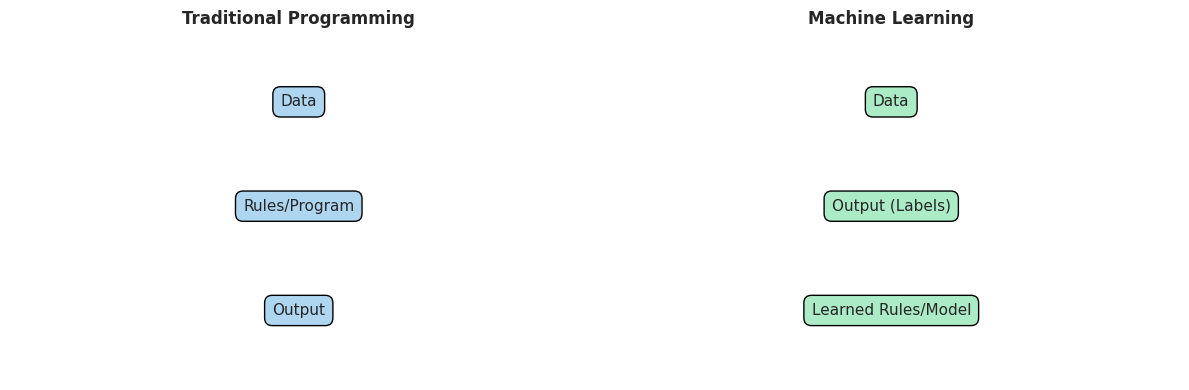

In [2]:
# Simple flowchart-style diagram: Traditional Programming vs Machine Learning
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Traditional Programming
ax[0].axis("off")
ax[0].set_title("Traditional Programming", fontsize=12, fontweight="bold")
boxes = [("Data", 0.5, 0.8), ("Rules/Program", 0.5, 0.5), ("Output", 0.5, 0.2)]
for text, x, y in boxes:
    ax[0].text(x, y, text, ha="center", va="center", fontsize=11,
               bbox=dict(boxstyle="round,pad=0.5", fc="#AED6F1", ec="black"))
ax[0].annotate("", xy=(0.5, 0.58), xytext=(0.5, 0.72), arrowprops=dict(arrowstyle="->"))
ax[0].annotate("", xy=(0.5, 0.28), xytext=(0.5, 0.42), arrowprops=dict(arrowstyle="->"))

# Machine Learning
ax[1].axis("off")
ax[1].set_title("Machine Learning", fontsize=12, fontweight="bold")
boxes = [("Data", 0.5, 0.8), ("Output (Labels)", 0.5, 0.5), ("Learned Rules/Model", 0.5, 0.2)]
for text, x, y in boxes:
    ax[1].text(x, y, text, ha="center", va="center", fontsize=11,
               bbox=dict(boxstyle="round,pad=0.5", fc="#ABEBC6", ec="black"))
ax[1].annotate("", xy=(0.5, 0.58), xytext=(0.5, 0.72), arrowprops=dict(arrowstyle="->"))
ax[1].annotate("", xy=(0.5, 0.28), xytext=(0.5, 0.42), arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
save_plot(fig, "01_traditional_vs_ml.png")
plt.show()


<a id="ch2"></a>
## 🧩 2. Types of Machine Learning
---


Machine Learning is broadly divided into **three types**:

| Type | Uses Labels? | Goal | Example Algorithm |
|------|--------------|------|--------------------|
| Supervised Learning | ✅ Yes | Predict output from input | Linear Regression, KNN |
| Unsupervised Learning | ❌ No | Find hidden patterns/groups | K-Means, PCA |
| Reinforcement Learning | 🎯 Reward signal | Learn by trial & error | Q-Learning, Deep Q-Network |

---


### 🟦 2.1 Supervised Learning

### 🧠 Simple Explanation
In supervised learning, we train the model using data that already has the correct answers (labels). The model learns the relationship between input and output, just like a student learning from a teacher with an answer key.

### 📖 Definition
> Supervised Learning is a type of ML where the model is trained on labeled data — each training example has an input and a known correct output.

### 🌍 Real-life Examples
- Predicting house prices from house features (price is the known label)
- Email spam classification (spam/not-spam label exists)
- Predicting exam pass/fail using study hours

### ✅ Advantages
- High accuracy with good labeled data
- Easy to evaluate using known outputs
- Well-understood algorithms

### ❌ Disadvantages
- Requires large labeled datasets (expensive)
- Doesn't generalize well outside training distribution

### 💼 Use Cases
- Credit scoring
- Medical diagnosis
- Price prediction

### ❓ Important Interview Questions
1. What is supervised learning? Give two real examples.
2. What is the difference between regression and classification?

---


### 🟩 2.2 Unsupervised Learning

### 🧠 Simple Explanation
In unsupervised learning, the data has no labels. The model tries to find structure, patterns, or groups on its own — like sorting fruits into groups by similarity without knowing their names.

### 📖 Definition
> Unsupervised Learning is a type of ML where the model finds hidden patterns or groupings in data that has no labeled output.

### 🌍 Real-life Examples
- Grouping customers by purchase behavior (customer segmentation)
- Grouping news articles by topic
- Anomaly detection in network traffic

### ✅ Advantages
- No need for labeled data
- Useful for discovering unknown patterns
- Good for exploratory data analysis

### ❌ Disadvantages
- Harder to evaluate (no ground truth)
- Results can be subjective/less accurate

### 💼 Use Cases
- Customer segmentation
- Market basket analysis
- Anomaly detection

### ❓ Important Interview Questions
1. What is unsupervised learning? How is it different from supervised learning?
2. Name two unsupervised learning algorithms.

---


### 🟨 2.3 Reinforcement Learning

### 🧠 Simple Explanation
In reinforcement learning, an 'agent' learns by interacting with an environment. It gets rewards for good actions and penalties for bad ones — similar to training a dog with treats.

### 📖 Definition
> Reinforcement Learning is a type of ML where an agent learns to make decisions by performing actions and receiving rewards or penalties from the environment.

### 🌍 Real-life Examples
- A robot learning to walk
- AlphaGo learning to play Go
- Self-driving cars learning to navigate traffic

### ✅ Advantages
- Learns optimal strategy through experience
- Works well in sequential decision-making problems

### ❌ Disadvantages
- Requires lots of trial and error (slow)
- Can be unstable / hard to train
- Needs careful reward design

### 💼 Use Cases
- Game playing AI
- Robotics
- Resource management
- Trading bots

### ❓ Important Interview Questions
1. What is reinforcement learning? Explain agent, environment, and reward.
2. How is reinforcement learning different from supervised learning?

---


✅ Saved: graphs/02_ml_types_pie.png


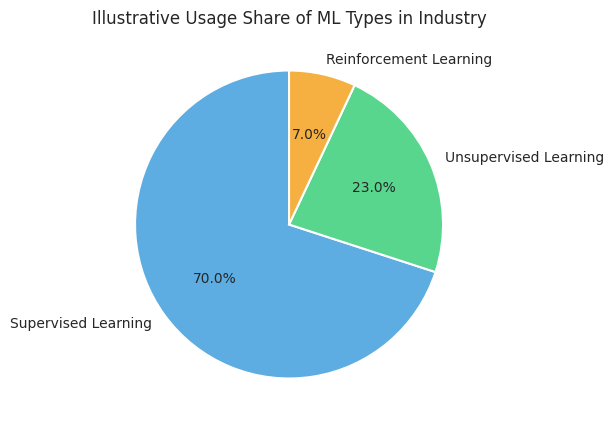

In [3]:
# Pie chart: proportion of ML types typically used in industry (illustrative)
fig, ax = plt.subplots()
labels = ["Supervised Learning", "Unsupervised Learning", "Reinforcement Learning"]
sizes = [70, 23, 7]
colors = ["#5DADE2", "#58D68D", "#F5B041"]
ax.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax.set_title("Illustrative Usage Share of ML Types in Industry")
save_plot(fig, "02_ml_types_pie.png")
plt.show()


<a id="ch3"></a>
## 🧹 3. Data Preprocessing
---


### 🧠 Simple Explanation
Real-world data is messy — it has missing values, different scales, and categorical text. Data preprocessing cleans and prepares this data so ML algorithms can understand it.

### 📖 Definition
> Data Preprocessing is the process of cleaning, transforming, and organizing raw data into a usable format before feeding it to a machine learning model.

### 🌍 Real-life Examples
- Filling missing age values in a survey with the average age
- Converting 'Male'/'Female' into 0/1 for the model
- Scaling income (in thousands) and age (in years) to the same range

### ✅ Advantages
- Improves model accuracy
- Reduces noise and bias
- Makes algorithms converge faster

### ❌ Disadvantages
- Time-consuming (up to 80% of project time)
- Wrong preprocessing can introduce bias

### 💼 Use Cases
- Every real-world ML project requires preprocessing

### ❓ Important Interview Questions
1. What is the difference between normalization and standardization?
2. How do you handle missing data?
3. What is one-hot encoding and when do you use it?
4. Why is feature scaling important for algorithms like KNN and SVM?

---


In [4]:
# Demonstration of preprocessing on a small synthetic dataset
np.random.seed(42)
df_demo = pd.DataFrame({
    "Age": [25, 32, np.nan, 45, 28, 60, np.nan, 22],
    "Salary": [50000, 64000, 58000, np.nan, 52000, 120000, 75000, 48000],
    "Gender": ["Male", "Female", "Female", "Male", "Male", "Female", "Male", "Female"],
    "Purchased": [0, 1, 0, 1, 0, 1, 1, 0]
})
print("Raw data with missing values:")
display(df_demo)

# Handle missing values with mean imputation
df_clean = df_demo.copy()
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].mean())
df_clean["Salary"] = df_clean["Salary"].fillna(df_clean["Salary"].mean())

# Encode categorical variable
le = LabelEncoder()
df_clean["Gender"] = le.fit_transform(df_clean["Gender"])

# Feature scaling
scaler = StandardScaler()
df_clean[["Age", "Salary"]] = scaler.fit_transform(df_clean[["Age", "Salary"]])

print("\nCleaned & scaled data:")
display(df_clean)

df_demo.to_csv(os.path.join(DATASETS_DIR, "preprocessing_demo_raw.csv"), index=False)
df_clean.to_csv(os.path.join(DATASETS_DIR, "preprocessing_demo_clean.csv"), index=False)


Raw data with missing values:


,Age,Salary,Gender,Purchased
0,25.0,50000.0,Male,0
1,32.0,64000.0,Female,1
2,NaN,58000.0,Female,0
3,45.0,NaN,Male,1
4,28.0,52000.0,Male,0
5,60.0,120000.0,Female,1
6,NaN,75000.0,Male,1
7,22.0,48000.0,Female,0



Cleaned & scaled data:


,Age,Salary,Gender,Purchased
0,-0.901395,-0.763155,1,0
1,-0.290773,-0.123931,0,1
2,0.000000,-0.397884,0,0
3,0.843241,0.000000,1,1
4,-0.639700,-0.671837,1,0
5,2.151717,2.432964,0,1
6,0.000000,0.378316,1,1
7,-1.163091,-0.854473,0,0


✅ Saved: graphs/03_missing_values_heatmap.png


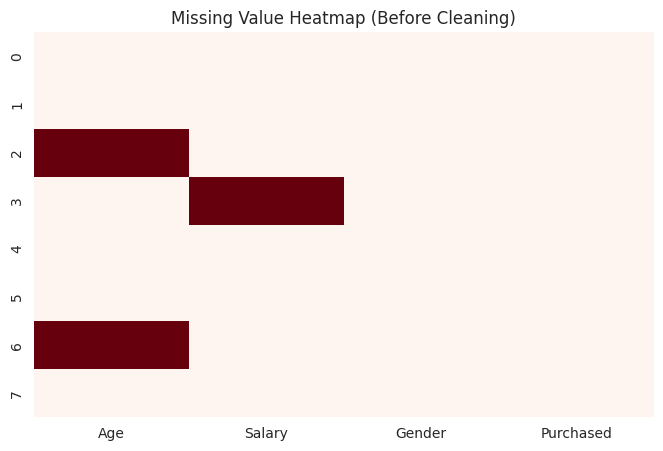

In [5]:
# Heatmap showing missing values before cleaning
fig, ax = plt.subplots()
sns.heatmap(df_demo.isnull(), cbar=False, cmap="Reds", ax=ax)
ax.set_title("Missing Value Heatmap (Before Cleaning)")
save_plot(fig, "03_missing_values_heatmap.png")
plt.show()


<a id="ch4"></a>
## ✂️ 4. Train-Test Split
---


### 🧠 Simple Explanation
Before training a model, we split our data into two (or three) parts: one part to train the model, and one part to test how well it performs on data it has never seen.

### 📖 Definition
> Train-Test Split is the technique of dividing a dataset into a training set (to fit the model) and a test set (to evaluate the model's performance on unseen data).

### 🌍 Real-life Examples
- Using 80% of student records to train a grade-predictor and 20% to test it
- Splitting 10 years of stock data into earlier years (train) and recent year (test)

### ✅ Advantages
- Helps detect overfitting
- Gives an honest estimate of real-world performance

### ❌ Disadvantages
- Reduces amount of data available for training
- A single split can be lucky/unlucky (solved by cross-validation)

### 💼 Use Cases
- Used in virtually every supervised learning project

### ❓ Important Interview Questions
1. Why do we split data into train and test sets?
2. What is a good train-test split ratio?
3. What is the difference between validation set and test set?
4. What is data leakage and how can train-test split prevent it?

---


Total samples: 150
Training samples: 120 (80%)
Testing samples:  30 (20%)


✅ Saved: graphs/04_train_test_split.png


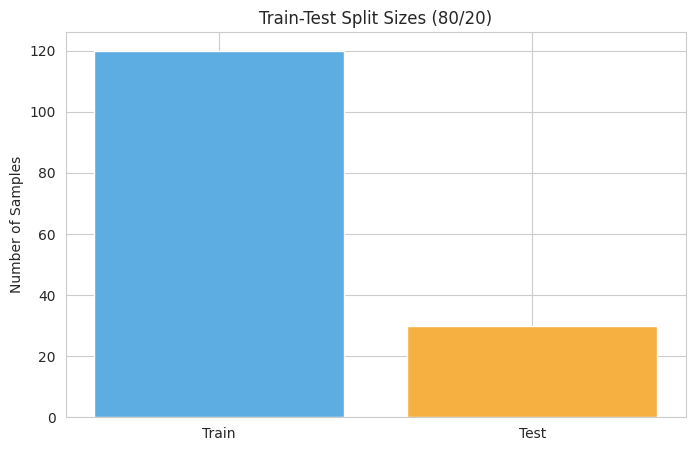

In [6]:
# Demonstrate train-test split using Iris dataset
iris = datasets.load_iris(as_frame=True)
X_iris, y_iris = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris)

print(f"Total samples: {len(X_iris)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X_iris):.0%})")
print(f"Testing samples:  {len(X_test)} ({len(X_test)/len(X_iris):.0%})")

fig, ax = plt.subplots()
ax.bar(["Train", "Test"], [len(X_train), len(X_test)], color=["#5DADE2", "#F5B041"])
ax.set_title("Train-Test Split Sizes (80/20)")
ax.set_ylabel("Number of Samples")
save_plot(fig, "04_train_test_split.png")
plt.show()

iris.frame.to_csv(os.path.join(DATASETS_DIR, "iris.csv"), index=False)


<a id="ch5"></a>
## 📈 5. Linear Regression
---


### 🧠 Simple Explanation
Linear Regression draws the best straight line through data points to predict a continuous number, like predicting house price from house size.

### 📖 Definition
> Linear Regression is a supervised learning algorithm that models the relationship between a dependent variable (y) and one or more independent variables (X) using a straight line: y = mX + c.

### 🌍 Real-life Examples
- Predicting house price from area in sq. ft.
- Predicting salary from years of experience
- Predicting sales from advertising spend

### ✅ Advantages
- Simple and fast
- Easy to interpret coefficients
- Works well for linearly related data

### ❌ Disadvantages
- Assumes linear relationship
- Sensitive to outliers
- Poor performance on complex/non-linear data

### 💼 Use Cases
- Real estate price prediction
- Sales forecasting
- Risk assessment

### ❓ Important Interview Questions
1. What is the cost function used in Linear Regression?
2. What assumptions does Linear Regression make?
3. What is the difference between simple and multiple linear regression?
4. What is multicollinearity and why is it a problem?
5. What is R-squared and what does it measure?

---


Coefficient (slope): 5135.19
Intercept: 29832.83
R2 Score: 0.981
MSE: 4990020.74
MAE: 2059.67


✅ Saved: graphs/05_linear_regression.png


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


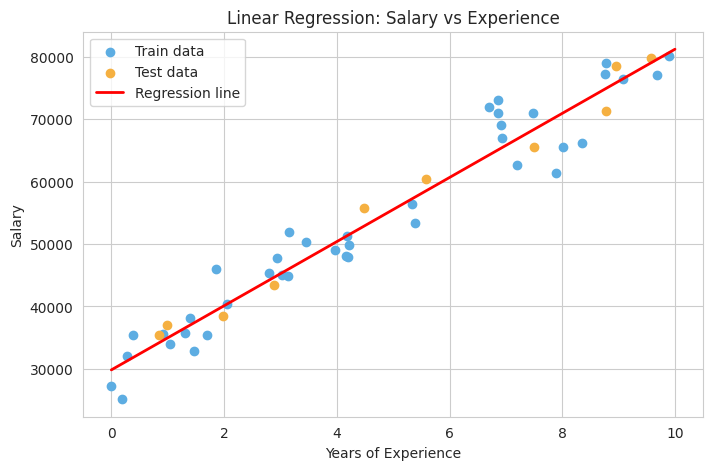

In [7]:
# Linear Regression demo: Experience vs Salary
np.random.seed(1)
experience = np.random.uniform(0, 10, 50)
salary = 30000 + 5000 * experience + np.random.normal(0, 4000, 50)
df_lr = pd.DataFrame({"YearsExperience": experience, "Salary": salary})
df_lr.to_csv(os.path.join(DATASETS_DIR, "salary_experience.csv"), index=False)

X = df_lr[["YearsExperience"]]
y = df_lr["Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print(f"Coefficient (slope): {lr_model.coef_[0]:.2f}")
print(f"Intercept: {lr_model.intercept_:.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

fig, ax = plt.subplots()
ax.scatter(X_train, y_train, color="#5DADE2", label="Train data")
ax.scatter(X_test, y_test, color="#F5B041", label="Test data")
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
ax.plot(x_line, lr_model.predict(x_line), color="red", linewidth=2, label="Regression line")
ax.set_xlabel("Years of Experience")
ax.set_ylabel("Salary")
ax.set_title("Linear Regression: Salary vs Experience")
ax.legend()
save_plot(fig, "05_linear_regression.png")
plt.show()


<a id="ch6"></a>
## 🔵 6. Logistic Regression
---


### 🧠 Simple Explanation
Despite its name, Logistic Regression is used for classification, not regression. It predicts the probability that something belongs to a category (e.g., spam or not spam) using an S-shaped (sigmoid) curve.

### 📖 Definition
> Logistic Regression is a supervised classification algorithm that uses the sigmoid function to model the probability of a binary (or multi-class) outcome.

### 🌍 Real-life Examples
- Predicting if an email is spam or not
- Predicting if a patient has a disease (yes/no)
- Predicting if a customer will churn

### ✅ Advantages
- Simple, fast, interpretable
- Outputs probabilities
- Works well for linearly separable classes

### ❌ Disadvantages
- Struggles with complex/non-linear relationships
- Sensitive to outliers and multicollinearity

### 💼 Use Cases
- Email spam detection
- Disease diagnosis
- Credit default prediction

### ❓ Important Interview Questions
1. Why is it called 'regression' if it's used for classification?
2. What is the sigmoid function?
3. What is the difference between Linear and Logistic Regression?
4. What is the decision boundary in Logistic Regression?
5. How do you handle multi-class classification with Logistic Regression?

---


Accuracy: 0.904
              precision    recall  f1-score   support

   malignant       0.90      0.84      0.87        43
      benign       0.91      0.94      0.92        71

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.90       114
weighted avg       0.90      0.90      0.90       114



✅ Saved: graphs/06_sigmoid_function.png


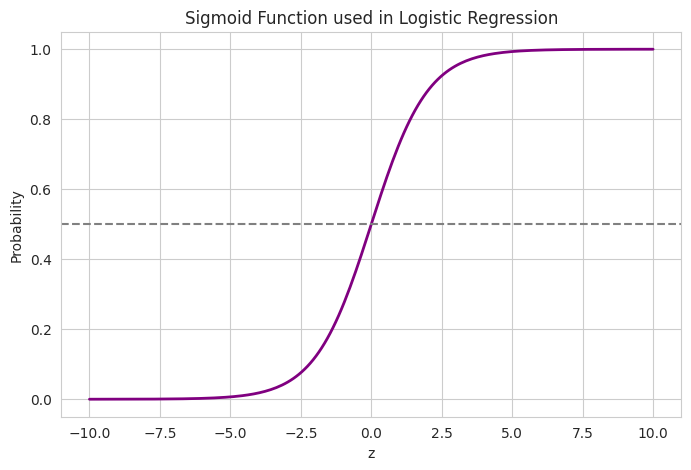

✅ Saved: graphs/06_logreg_decision_boundary.png


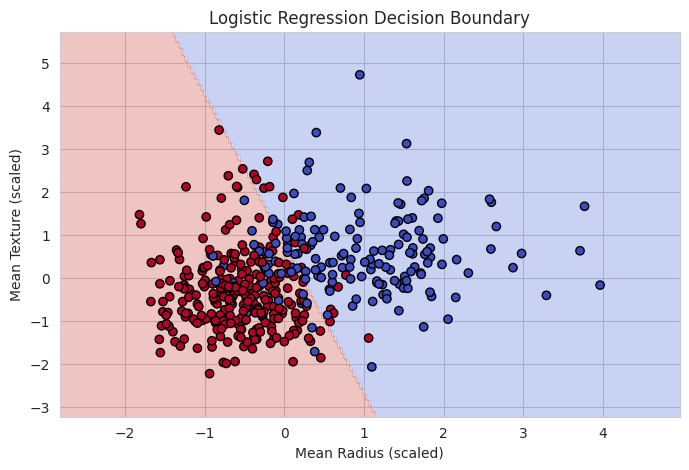

In [8]:
# Logistic Regression demo using Breast Cancer dataset
cancer = datasets.load_breast_cancer(as_frame=True)
X = cancer.data[["mean radius", "mean texture"]]
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_s, y_train)
y_pred = log_model.predict(X_test_s)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

# Sigmoid curve illustration
fig, ax = plt.subplots()
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))
ax.plot(z, sigmoid, color="purple", linewidth=2)
ax.axhline(0.5, color="gray", linestyle="--")
ax.set_title("Sigmoid Function used in Logistic Regression")
ax.set_xlabel("z")
ax.set_ylabel("Probability")
save_plot(fig, "06_sigmoid_function.png")
plt.show()

# Decision boundary plot
fig, ax = plt.subplots()
x_min, x_max = X_train_s[:, 0].min() - 1, X_train_s[:, 0].max() + 1
y_min, y_max = X_train_s[:, 1].min() - 1, X_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = log_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
ax.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train, cmap="coolwarm", edgecolor="k")
ax.set_title("Logistic Regression Decision Boundary")
ax.set_xlabel("Mean Radius (scaled)")
ax.set_ylabel("Mean Texture (scaled)")
save_plot(fig, "06_logreg_decision_boundary.png")
plt.show()

cancer.frame.to_csv(os.path.join(DATASETS_DIR, "breast_cancer.csv"), index=False)


<a id="ch7"></a>
## 📍 7. K-Nearest Neighbors (KNN)
---


### 🧠 Simple Explanation
KNN classifies a new data point by looking at its 'K' closest neighbors and taking a majority vote. It's like asking your K nearest friends for an opinion and going with the majority.

### 📖 Definition
> K-Nearest Neighbors is a non-parametric, instance-based supervised learning algorithm that classifies a data point based on the majority class among its K nearest neighbors in feature space.

### 🌍 Real-life Examples
- Recommending products similar to what a user bought
- Classifying a flower species based on similar flowers
- Detecting handwriting digits

### ✅ Advantages
- Simple, intuitive, no training phase
- Works well with small datasets
- Naturally handles multi-class problems

### ❌ Disadvantages
- Slow prediction on large datasets
- Sensitive to irrelevant features and feature scale
- Choosing right K is tricky

### 💼 Use Cases
- Recommendation systems
- Pattern recognition
- Anomaly detection

### ❓ Important Interview Questions
1. How do you choose the right value of K?
2. Why is feature scaling important for KNN?
3. What is the time complexity of KNN at prediction time?
4. What distance metrics can be used in KNN?

---


KNN Accuracy: 0.967


✅ Saved: graphs/07_knn_accuracy_vs_k.png


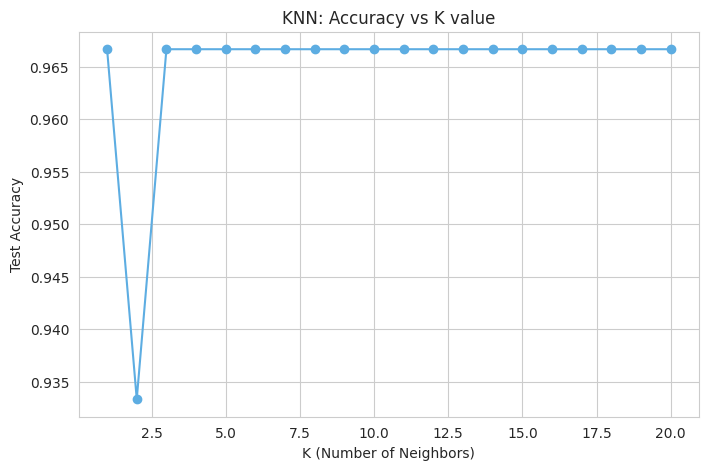

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


✅ Saved: graphs/07_knn_decision_boundary.png


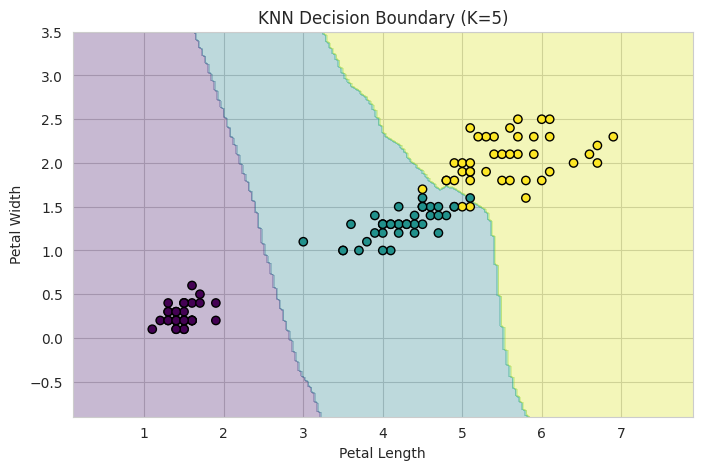

In [9]:
# KNN demo on Iris dataset (2 features for visualization)
X = iris.data[["petal length (cm)", "petal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Accuracy vs K plot
ks = range(1, 21)
accs = []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    accs.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots()
ax.plot(list(ks), accs, marker="o", color="#5DADE2")
ax.set_xlabel("K (Number of Neighbors)")
ax.set_ylabel("Test Accuracy")
ax.set_title("KNN: Accuracy vs K value")
save_plot(fig, "07_knn_accuracy_vs_k.png")
plt.show()

# Decision boundary
fig, ax = plt.subplots()
x_min, x_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
y_min, y_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
ax.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, cmap="viridis", edgecolor="k")
ax.set_title("KNN Decision Boundary (K=5)")
ax.set_xlabel("Petal Length")
ax.set_ylabel("Petal Width")
save_plot(fig, "07_knn_decision_boundary.png")
plt.show()


<a id="ch8"></a>
## 🌳 8. Decision Trees
---


### 🧠 Simple Explanation
A Decision Tree splits data into branches based on feature values, like a flowchart of yes/no questions, until it reaches a final decision (leaf).

### 📖 Definition
> A Decision Tree is a supervised learning algorithm that splits data recursively based on feature values to form a tree-like structure of decisions, used for both classification and regression.

### 🌍 Real-life Examples
- Deciding loan approval based on income, credit score, age
- Medical diagnosis flowcharts
- Deciding whether to play outside based on weather

### ✅ Advantages
- Easy to understand and visualize
- Handles both numerical and categorical data
- No need for feature scaling

### ❌ Disadvantages
- Prone to overfitting
- Unstable (small data changes can change the tree)
- Biased toward features with more levels

### 💼 Use Cases
- Credit risk assessment
- Medical diagnosis
- Customer churn prediction

### ❓ Important Interview Questions
1. What is entropy and information gain?
2. What is Gini impurity?
3. How do you prevent a decision tree from overfitting?
4. What is pruning?
5. How does a decision tree handle continuous variables?

---


Decision Tree Accuracy: 0.967


✅ Saved: graphs/08_decision_tree.png


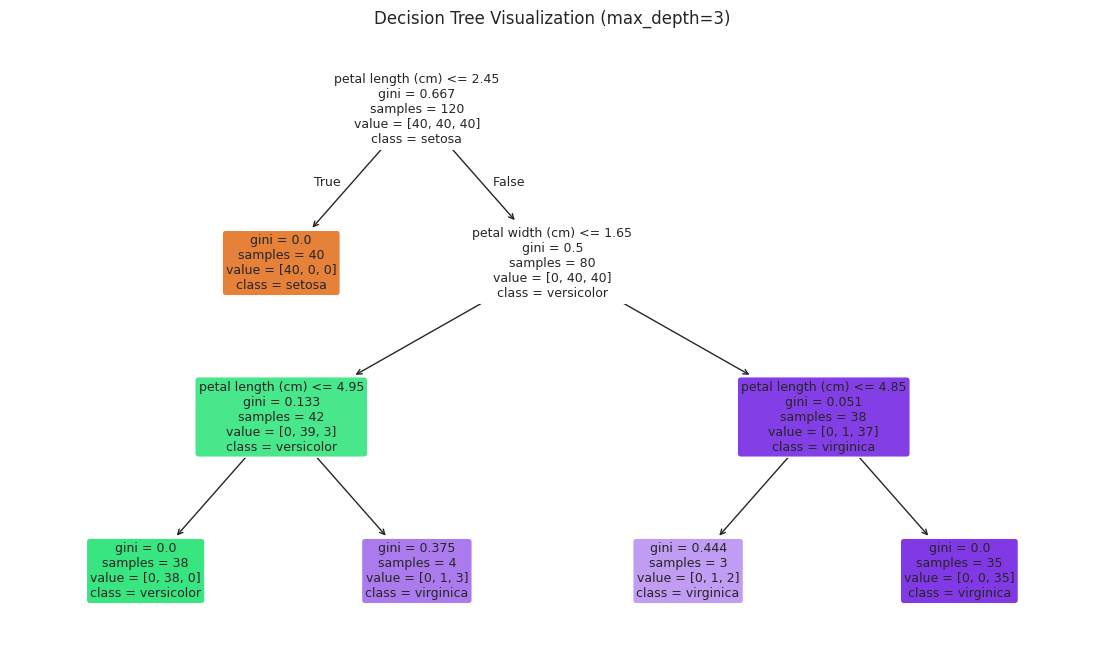

✅ Saved: graphs/08_dt_feature_importance.png


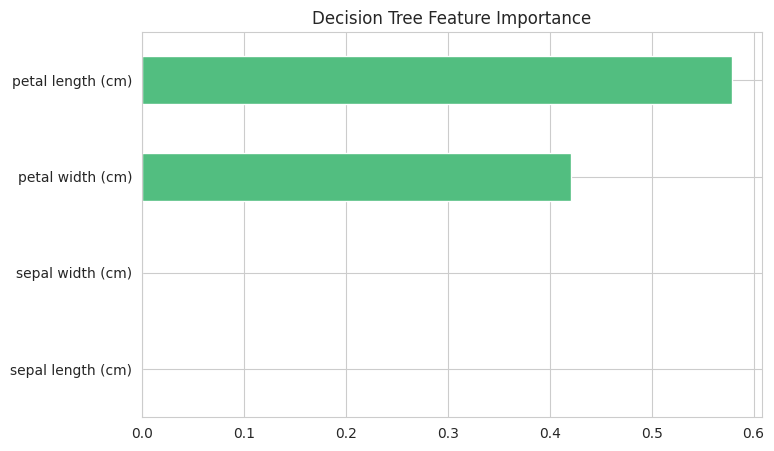

In [10]:
# Decision Tree demo on Iris
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred):.3f}")

fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree Visualization (max_depth=3)")
save_plot(fig, "08_decision_tree.png")
plt.show()

# Feature importance bar chart
fig, ax = plt.subplots()
importances = pd.Series(dt.feature_importances_, index=iris.feature_names).sort_values()
importances.plot(kind="barh", ax=ax, color="#52BE80")
ax.set_title("Decision Tree Feature Importance")
save_plot(fig, "08_dt_feature_importance.png")
plt.show()


<a id="ch9"></a>
## 🌲🌲🌲 9. Random Forest
---


### 🧠 Simple Explanation
A Random Forest builds many decision trees on random subsets of data and features, then combines their votes. Many trees together usually make better, more stable decisions than one tree.

### 📖 Definition
> Random Forest is an ensemble learning algorithm that builds multiple decision trees on bootstrapped samples of data and aggregates their predictions (majority vote for classification, average for regression).

### 🌍 Real-life Examples
- Predicting loan default by combining hundreds of small decision trees
- Image classification
- Predicting customer churn with high accuracy

### ✅ Advantages
- Reduces overfitting compared to a single tree
- Handles large datasets and high dimensionality well
- Provides feature importance

### ❌ Disadvantages
- Less interpretable than a single tree
- Slower to train and predict with many trees
- Larger model size

### 💼 Use Cases
- Fraud detection
- Stock market prediction
- Recommendation engines

### ❓ Important Interview Questions
1. What is bagging and how does Random Forest use it?
2. How is Random Forest different from a single Decision Tree?
3. What is out-of-bag (OOB) error?
4. How do you tune the number of trees in a Random Forest?

---


Random Forest Accuracy: 0.967


✅ Saved: graphs/09_rf_feature_importance.png


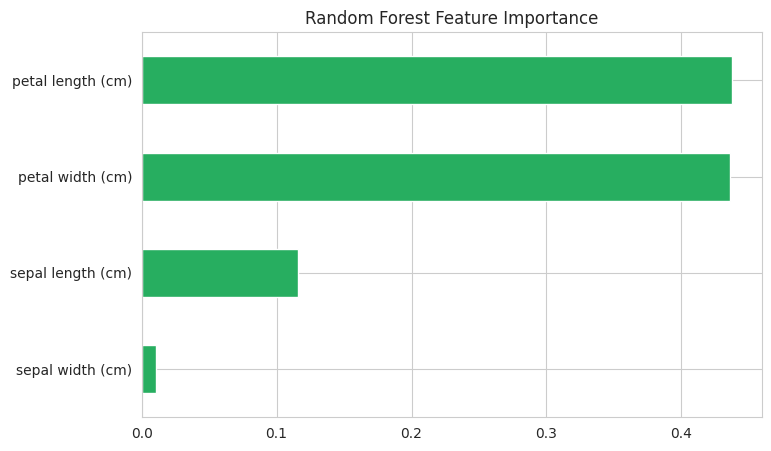

✅ Saved: graphs/09_rf_confusion_matrix.png


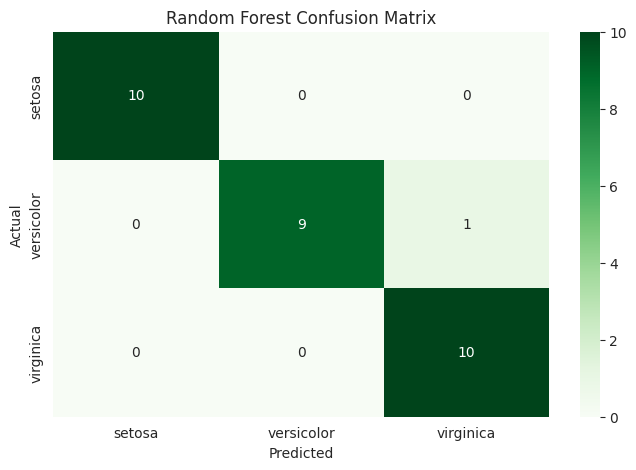

In [11]:
# Random Forest demo on Iris
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred):.3f}")

fig, ax = plt.subplots()
importances = pd.Series(rf.feature_importances_, index=iris.feature_names).sort_values()
importances.plot(kind="barh", ax=ax, color="#27AE60")
ax.set_title("Random Forest Feature Importance")
save_plot(fig, "09_rf_feature_importance.png")
plt.show()

# Confusion Matrix for Random Forest
fig, ax = plt.subplots()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=iris.target_names, yticklabels=iris.target_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Confusion Matrix")
save_plot(fig, "09_rf_confusion_matrix.png")
plt.show()


<a id="ch10"></a>
## 🛡️ 10. Support Vector Machine (SVM)
---


### 🧠 Simple Explanation
SVM tries to find the best boundary (line/plane) that separates classes with the maximum possible margin between them, so new points are classified confidently.

### 📖 Definition
> Support Vector Machine is a supervised learning algorithm that finds the optimal hyperplane which maximizes the margin between classes, using 'support vectors' (closest points) to define the boundary.

### 🌍 Real-life Examples
- Classifying handwritten digits
- Face detection
- Text/document classification

### ✅ Advantages
- Effective in high-dimensional spaces
- Works well with clear margin of separation
- Kernel trick handles non-linear data

### ❌ Disadvantages
- Slow on large datasets
- Hard to tune kernel/hyperparameters
- Less effective with overlapping classes / noisy data

### 💼 Use Cases
- Image classification
- Bioinformatics (gene classification)
- Text categorization

### ❓ Important Interview Questions
1. What is a hyperplane and support vectors?
2. What is the kernel trick? Name common kernels.
3. What is the role of the C parameter in SVM?
4. What is margin maximization?

---


SVM Accuracy: 0.967


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


✅ Saved: graphs/10_svm_decision_boundary.png


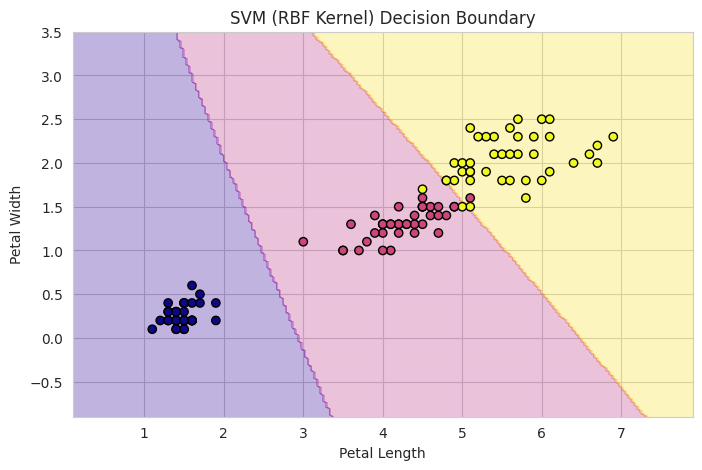

In [12]:
# SVM demo with decision boundary on Iris (2 features)
X = iris.data[["petal length (cm)", "petal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

svm_model = SVC(kernel="rbf", C=1, gamma="scale")
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred):.3f}")

fig, ax = plt.subplots()
x_min, x_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
y_min, y_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap="plasma")
ax.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, cmap="plasma", edgecolor="k")
ax.set_title("SVM (RBF Kernel) Decision Boundary")
ax.set_xlabel("Petal Length")
ax.set_ylabel("Petal Width")
save_plot(fig, "10_svm_decision_boundary.png")
plt.show()


<a id="ch11"></a>
## 🎲 11. Naive Bayes
---


### 🧠 Simple Explanation
Naive Bayes uses probability (Bayes' Theorem) to predict the class of new data. It's called 'naive' because it assumes all features are independent of each other, which is rarely true but still works surprisingly well.

### 📖 Definition
> Naive Bayes is a probabilistic supervised learning algorithm based on Bayes' Theorem that assumes feature independence to calculate the probability of each class given the input features.

### 🌍 Real-life Examples
- Spam email filtering
- Sentiment analysis of reviews
- Disease prediction from symptoms

### ✅ Advantages
- Very fast to train and predict
- Works well with small data and text data
- Performs well even when independence assumption is violated

### ❌ Disadvantages
- Independence assumption rarely true in real life
- Can be outperformed by more complex models
- Zero-frequency problem for unseen categories

### 💼 Use Cases
- Spam detection
- Sentiment analysis
- Document classification

### ❓ Important Interview Questions
1. State Bayes' Theorem.
2. Why is Naive Bayes called 'naive'?
3. What is the zero-frequency problem and how is it solved (Laplace smoothing)?
4. What types of Naive Bayes exist (Gaussian, Multinomial, Bernoulli)?

---


Naive Bayes Accuracy: 0.974


✅ Saved: graphs/11_nb_confusion_matrix.png


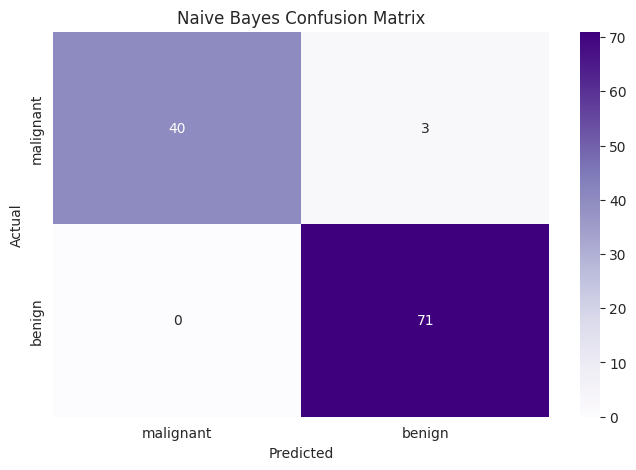

In [13]:
# Naive Bayes demo on Breast Cancer dataset
X = cancer.data
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred):.3f}")

fig, ax = plt.subplots()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Naive Bayes Confusion Matrix")
save_plot(fig, "11_nb_confusion_matrix.png")
plt.show()


<a id="ch12"></a>
## 🔗 12. Clustering (K-Means, Hierarchical)
---


### 🧠 Simple Explanation
Clustering groups similar data points together without using labels. K-Means groups points around 'K' centers, while Hierarchical Clustering builds a tree of nested groups.

### 📖 Definition
> Clustering is an unsupervised learning technique that groups a set of data points such that points in the same group (cluster) are more similar to each other than to points in other groups.

### 🌍 Real-life Examples
- Grouping customers by shopping behavior
- Grouping news articles by topic
- Grouping genes with similar expression patterns

### ✅ Advantages
- No labeled data required
- Useful for exploratory analysis
- Scales reasonably well (K-Means)

### ❌ Disadvantages
- Must choose number of clusters K in advance (K-Means)
- Sensitive to initial centroids and outliers
- Hierarchical clustering is slow on large datasets

### 💼 Use Cases
- Customer segmentation
- Image compression
- Document/topic clustering

### ❓ Important Interview Questions
1. How does the K-Means algorithm work step by step?
2. How do you choose the optimal number of clusters (Elbow method, Silhouette score)?
3. What is the difference between K-Means and Hierarchical Clustering?
4. What are the limitations of K-Means?

---


✅ Saved: graphs/12_kmeans_clusters.png


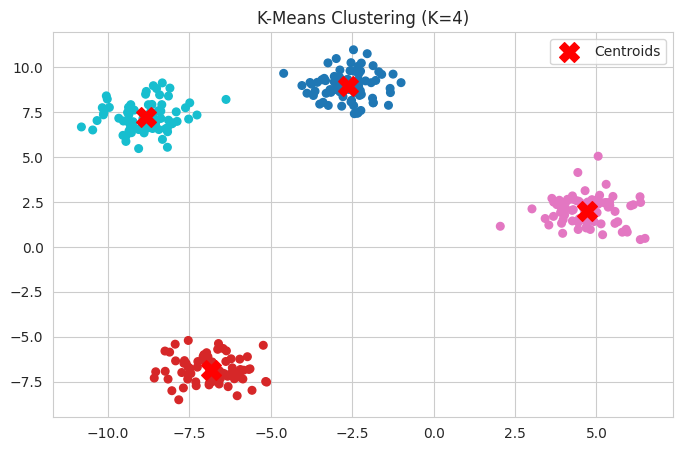

✅ Saved: graphs/12_kmeans_elbow.png


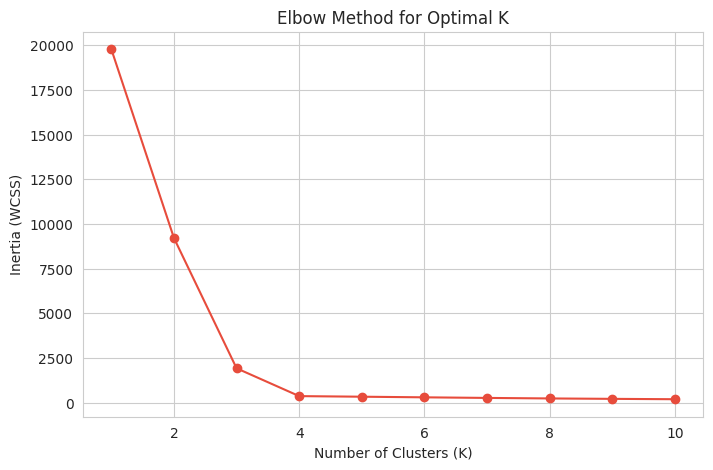

✅ Saved: graphs/12_dendrogram.png


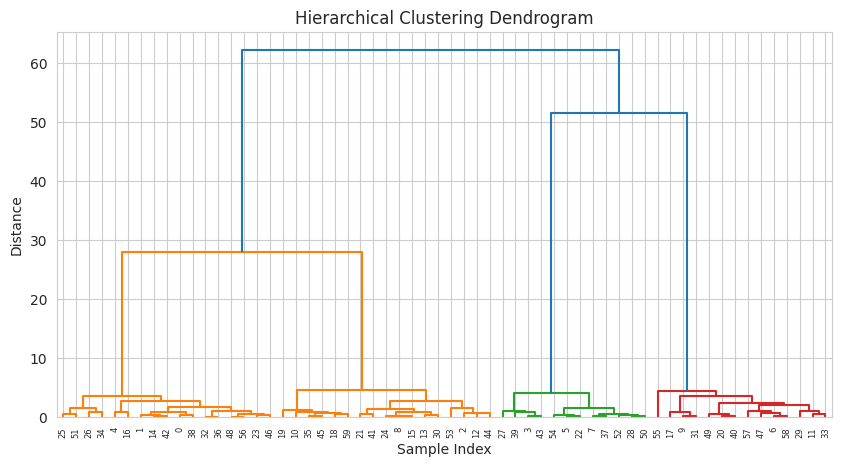

In [14]:
# K-Means clustering demo
from sklearn.datasets import make_blobs
X_blob, y_blob = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_blob)

fig, ax = plt.subplots()
scatter = ax.scatter(X_blob[:, 0], X_blob[:, 1], c=clusters, cmap="tab10", s=30)
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
           marker="X", s=200, c="red", label="Centroids")
ax.set_title("K-Means Clustering (K=4)")
ax.legend()
save_plot(fig, "12_kmeans_clusters.png")
plt.show()

# Elbow Method
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_blob)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(list(K_range), inertias, marker="o", color="#E74C3C")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (WCSS)")
ax.set_title("Elbow Method for Optimal K")
save_plot(fig, "12_kmeans_elbow.png")
plt.show()

# Hierarchical Clustering Dendrogram
fig, ax = plt.subplots(figsize=(10, 5))
linked = linkage(X_blob[:60], method="ward")
dendrogram(linked, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram")
ax.set_xlabel("Sample Index")
ax.set_ylabel("Distance")
save_plot(fig, "12_dendrogram.png")
plt.show()


<a id="ch13"></a>
## 📉 13. Principal Component Analysis (PCA)
---


### 🧠 Simple Explanation
PCA reduces the number of features in a dataset while keeping as much important information as possible. It compresses data into fewer 'principal component' dimensions, making it easier to visualize and faster to process.

### 📖 Definition
> PCA is an unsupervised dimensionality reduction technique that transforms correlated features into a smaller set of uncorrelated variables called principal components, ordered by the amount of variance they explain.

### 🌍 Real-life Examples
- Compressing a 100-feature dataset into 2 features for visualization
- Reducing noise in image data
- Speeding up training of ML models with many features

### ✅ Advantages
- Reduces dimensionality and noise
- Speeds up training
- Helps visualize high-dimensional data

### ❌ Disadvantages
- Principal components are hard to interpret
- Can lose some information
- Sensitive to feature scaling

### 💼 Use Cases
- Image compression
- Visualization of high-dimensional data
- Preprocessing before clustering or classification

### ❓ Important Interview Questions
1. What is the goal of PCA?
2. What is explained variance ratio?
3. Why is feature scaling needed before PCA?
4. What is the difference between PCA and feature selection?

---


Explained variance ratio: [0.44272026 0.18971182]
Total variance explained by 2 components: 63.24%


✅ Saved: graphs/13_pca_2d.png


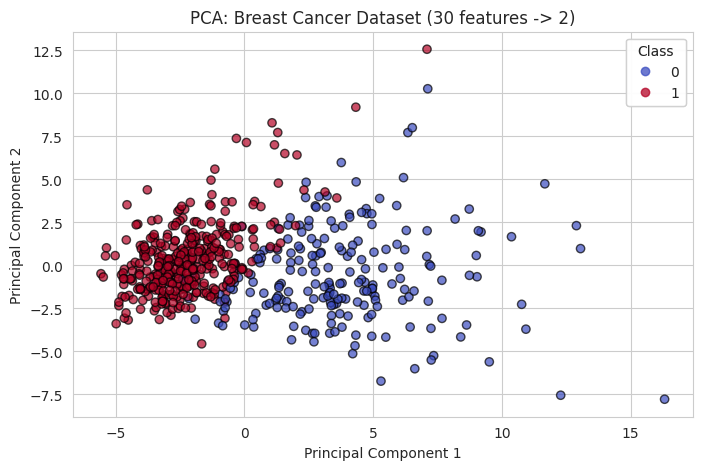

✅ Saved: graphs/13_pca_variance.png


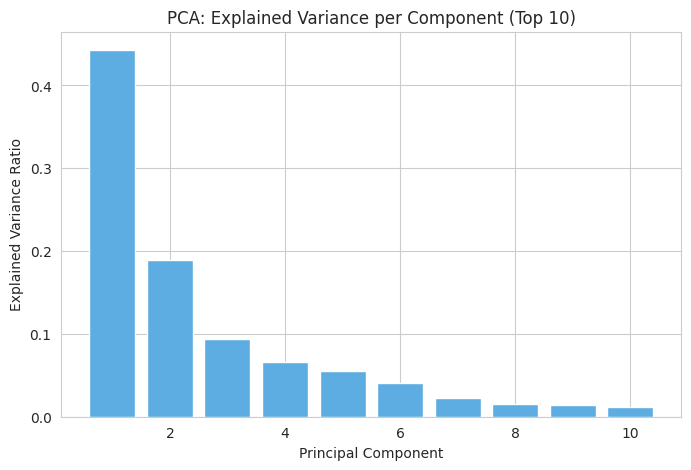

In [15]:
# PCA demo on Breast Cancer dataset (reduce 30 features to 2)
X = cancer.data
y = cancer.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.2%}")

fig, ax = plt.subplots()
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolor="k", alpha=0.7)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("PCA: Breast Cancer Dataset (30 features -> 2)")
legend1 = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend1)
save_plot(fig, "13_pca_2d.png")
plt.show()

# Explained variance bar chart
pca_full = PCA().fit(X_scaled)
fig, ax = plt.subplots()
ax.bar(range(1, 11), pca_full.explained_variance_ratio_[:10], color="#5DADE2")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA: Explained Variance per Component (Top 10)")
save_plot(fig, "13_pca_variance.png")
plt.show()


<a id="ch14"></a>
## 🧠⚡ 14. Neural Networks
---


### 🧠 Simple Explanation
A Neural Network is inspired by the human brain. It has layers of connected 'neurons' that take inputs, apply weights and activation functions, and pass signals forward to make a prediction.

### 📖 Definition
> A Neural Network is a computational model made of layers of interconnected nodes (neurons) — an input layer, one or more hidden layers, and an output layer — that learns patterns by adjusting connection weights through backpropagation.

### 🌍 Real-life Examples
- Handwritten digit recognition (MNIST)
- Voice assistants understanding speech
- Predicting customer churn with non-linear patterns

### ✅ Advantages
- Can model complex, non-linear relationships
- Scales well with large data
- Forms the foundation of Deep Learning

### ❌ Disadvantages
- Needs lots of data and compute
- 'Black box' - hard to interpret
- Prone to overfitting without regularization

### 💼 Use Cases
- Image recognition
- Speech recognition
- Natural language processing

### ❓ Important Interview Questions
1. What is a perceptron?
2. What is an activation function? Name a few (ReLU, Sigmoid, Tanh).
3. What is backpropagation?
4. What is the vanishing gradient problem?
5. What is the difference between a shallow and a deep neural network?

---


✅ Saved: graphs/14_neural_network_architecture.png


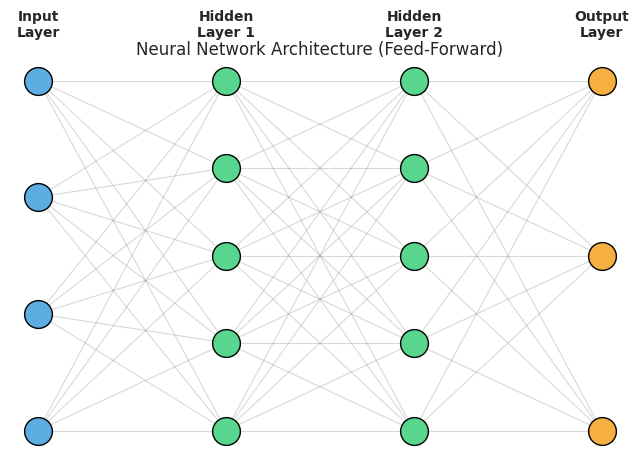

Neural Network (MLP) Accuracy: 0.967
✅ Saved: graphs/14_nn_loss_curve.png


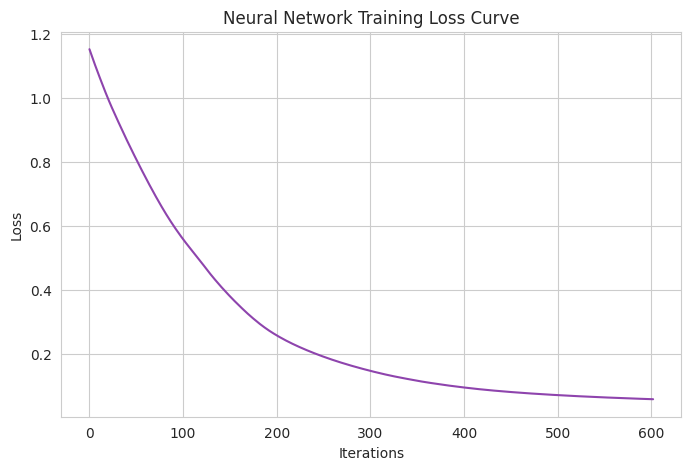

In [16]:
# Neural Network architecture diagram (simple feed-forward illustration)
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis("off")

layer_sizes = [4, 5, 5, 3]
layer_names = ["Input\nLayer", "Hidden\nLayer 1", "Hidden\nLayer 2", "Output\nLayer"]
x_positions = np.linspace(0.1, 0.9, len(layer_sizes))

positions = {}
for li, (size, xpos) in enumerate(zip(layer_sizes, x_positions)):
    y_positions = np.linspace(0.1, 0.9, size)
    for ni, ypos in enumerate(y_positions):
        positions[(li, ni)] = (xpos, ypos)
        color = "#5DADE2" if li == 0 else ("#F5B041" if li == len(layer_sizes)-1 else "#58D68D")
        ax.scatter(xpos, ypos, s=400, c=color, edgecolor="black", zorder=3)

for li in range(len(layer_sizes)-1):
    for ni in range(layer_sizes[li]):
        for nj in range(layer_sizes[li+1]):
            x1, y1 = positions[(li, ni)]
            x2, y2 = positions[(li+1, nj)]
            ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.3, linewidth=0.8, zorder=1)

for name, xpos in zip(layer_names, x_positions):
    ax.text(xpos, 1.0, name, ha="center", fontsize=10, fontweight="bold")

ax.set_title("Neural Network Architecture (Feed-Forward)")
save_plot(fig, "14_neural_network_architecture.png")
plt.show()

# Train a small MLP classifier on Iris
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=2000, random_state=42)
mlp.fit(X_train_s, y_train)
y_pred = mlp.predict(X_test_s)
print(f"Neural Network (MLP) Accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Loss curve
fig, ax = plt.subplots()
ax.plot(mlp.loss_curve_, color="#8E44AD")
ax.set_xlabel("Iterations")
ax.set_ylabel("Loss")
ax.set_title("Neural Network Training Loss Curve")
save_plot(fig, "14_nn_loss_curve.png")
plt.show()


<a id="ch15"></a>
## 🧬 15. Deep Learning Basics
---


### 🧠 Simple Explanation
Deep Learning is Machine Learning using neural networks with many hidden layers ('deep' networks). These deep networks can automatically learn complex features from raw data like images, audio, and text.

### 📖 Definition
> Deep Learning is a subset of Machine Learning that uses multi-layered (deep) neural networks to automatically learn hierarchical feature representations directly from raw data.

### 🌍 Real-life Examples
- Convolutional Neural Networks (CNNs) for image recognition
- Recurrent Neural Networks (RNNs) for sequence/text data
- Transformers for language models like ChatGPT

### ✅ Advantages
- Automatically extracts features (no manual feature engineering)
- State-of-the-art performance on images, text, audio
- Scales extremely well with data and compute

### ❌ Disadvantages
- Needs huge amounts of data
- Very compute-intensive (GPUs/TPUs)
- Hard to interpret, prone to overfitting on small data

### 💼 Use Cases
- Computer vision
- Natural language processing
- Speech recognition
- Generative AI

### ❓ Important Interview Questions
1. What is the difference between Machine Learning and Deep Learning?
2. What is a Convolutional Neural Network (CNN) used for?
3. What is a Recurrent Neural Network (RNN) used for?
4. What is transfer learning?
5. What is the role of GPUs in deep learning?

---


✅ Saved: graphs/15_ml_vs_dl_pipeline.png


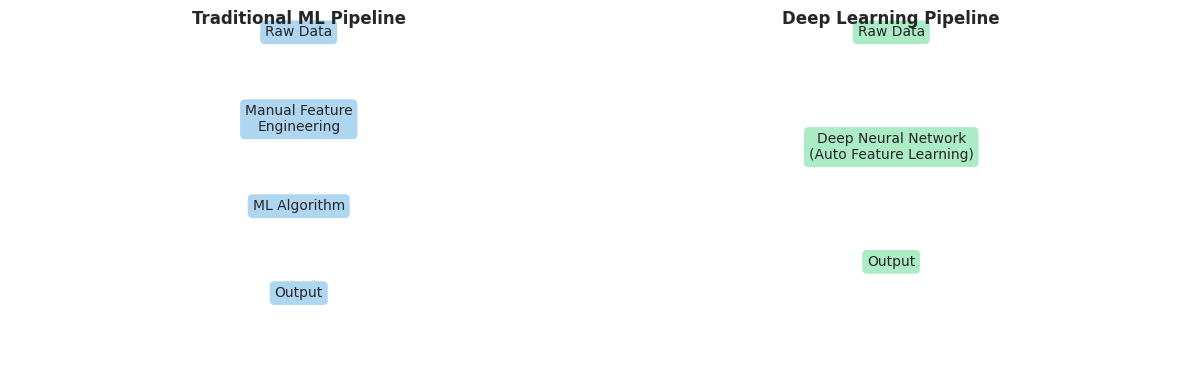

In [17]:
# Diagram comparing ML vs DL feature engineering pipeline
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].axis("off")
ax[0].set_title("Traditional ML Pipeline", fontweight="bold")
steps = ["Raw Data", "Manual Feature\nEngineering", "ML Algorithm", "Output"]
for i, s in enumerate(steps):
    ax[0].text(0.5, 1 - i*0.25, s, ha="center", va="center", fontsize=10,
               bbox=dict(boxstyle="round,pad=0.4", fc="#AED6F1"))
    if i > 0:
        ax[0].annotate("", xy=(0.5, 1.07 - i*0.25), xytext=(0.5, 1.0 - (i-1)*0.25 - 0.07),
                        arrowprops=dict(arrowstyle="->"))

ax[1].axis("off")
ax[1].set_title("Deep Learning Pipeline", fontweight="bold")
steps2 = ["Raw Data", "Deep Neural Network\n(Auto Feature Learning)", "Output"]
for i, s in enumerate(steps2):
    ax[1].text(0.5, 1 - i*0.33, s, ha="center", va="center", fontsize=10,
               bbox=dict(boxstyle="round,pad=0.4", fc="#ABEBC6"))
    if i > 0:
        ax[1].annotate("", xy=(0.5, 1.1 - i*0.33), xytext=(0.5, 1.0 - (i-1)*0.33 - 0.1),
                        arrowprops=dict(arrowstyle="->"))

plt.tight_layout()
save_plot(fig, "15_ml_vs_dl_pipeline.png")
plt.show()


<a id="ch16"></a>
## 📊 16. Model Evaluation Metrics
---


### 🧠 Simple Explanation
After training a model, we need to measure how good it is. Different metrics tell us different things — accuracy alone can be misleading, especially with imbalanced data.

### 📖 Key Classification Metrics

| Metric | Formula | What it tells us |
|--------|---------|-------------------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Overall correctness |
| Precision | TP/(TP+FP) | Of predicted positives, how many were correct |
| Recall (Sensitivity) | TP/(TP+FN) | Of actual positives, how many were found |
| F1-Score | 2×(P×R)/(P+R) | Balance between Precision & Recall |
| ROC-AUC | Area under ROC curve | Ability to distinguish classes |

### 📖 Key Regression Metrics

| Metric | Formula | What it tells us |
|--------|---------|-------------------|
| MAE | mean(\|y - ŷ\|) | Average absolute error |
| MSE | mean((y - ŷ)²) | Penalizes large errors more |
| RMSE | sqrt(MSE) | Error in original units |
| R² Score | 1 - SS_res/SS_tot | Proportion of variance explained |

### 🌍 Real-life Examples
- In cancer detection, **Recall** matters more (don't want to miss any sick patient)
- In spam detection, **Precision** matters more (don't want to mark important mail as spam)

### ❓ Important Interview Questions
1. What is the difference between Precision and Recall?
2. When would you prioritize Recall over Precision?
3. What is a Confusion Matrix?
4. What is ROC-AUC and how do you interpret it?
5. Why is accuracy a poor metric for imbalanced datasets?

---


Accuracy:  0.974
Precision: 0.972
Recall:    0.986
F1-score:  0.979


✅ Saved: graphs/16_confusion_matrix.png


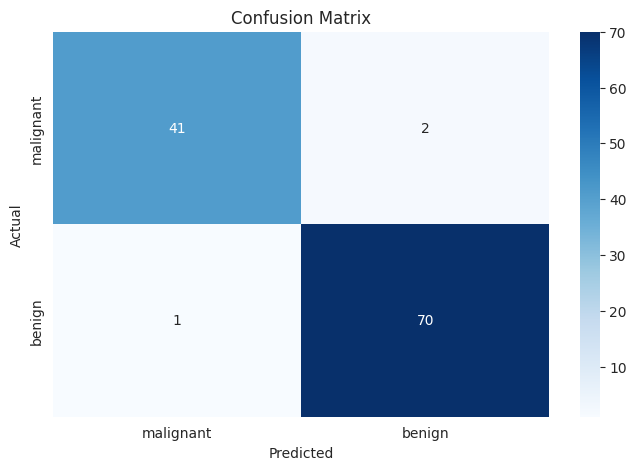

✅ Saved: graphs/16_roc_curve.png


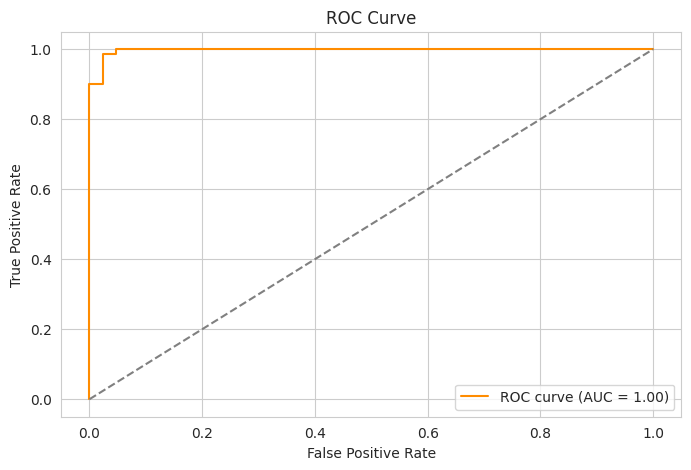

In [18]:
# Confusion Matrix, ROC Curve example using Logistic Regression on Breast Cancer data
X = cancer.data
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")

# Confusion Matrix
fig, ax = plt.subplots()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names, yticklabels=cancer.target_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
save_plot(fig, "16_confusion_matrix.png")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots()
ax.plot(fpr, tpr, color="darkorange", label=f"ROC curve (AUC = {roc_auc:.2f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
save_plot(fig, "16_roc_curve.png")
plt.show()


<a id="ch17"></a>
## ⚖️ 17. Overfitting and Underfitting
---


### 🧠 Simple Explanation
Overfitting is when a model memorizes the training data too well and fails on new data, like a student who memorizes answers but doesn't understand the concept. Underfitting is when a model is too simple to capture patterns, like not studying enough.

### 📖 Definition
> Overfitting occurs when a model learns noise in training data and performs poorly on unseen data (high variance). Underfitting occurs when a model is too simple to capture underlying patterns (high bias).

### 🌍 Real-life Examples
- A decision tree with unlimited depth memorizing every training example (overfitting)
- A straight line trying to fit a clearly curved dataset (underfitting)

### ✅ Advantages


### ❌ Disadvantages


### 💼 Use Cases
- Understanding bias-variance tradeoff is essential for every ML model

### ❓ Important Interview Questions
1. What is the bias-variance tradeoff?
2. How do you detect overfitting?
3. Name techniques to reduce overfitting (regularization, dropout, early stopping, more data, simpler model).
4. Name techniques to reduce underfitting.

---


✅ Saved: graphs/17_overfit_underfit.png


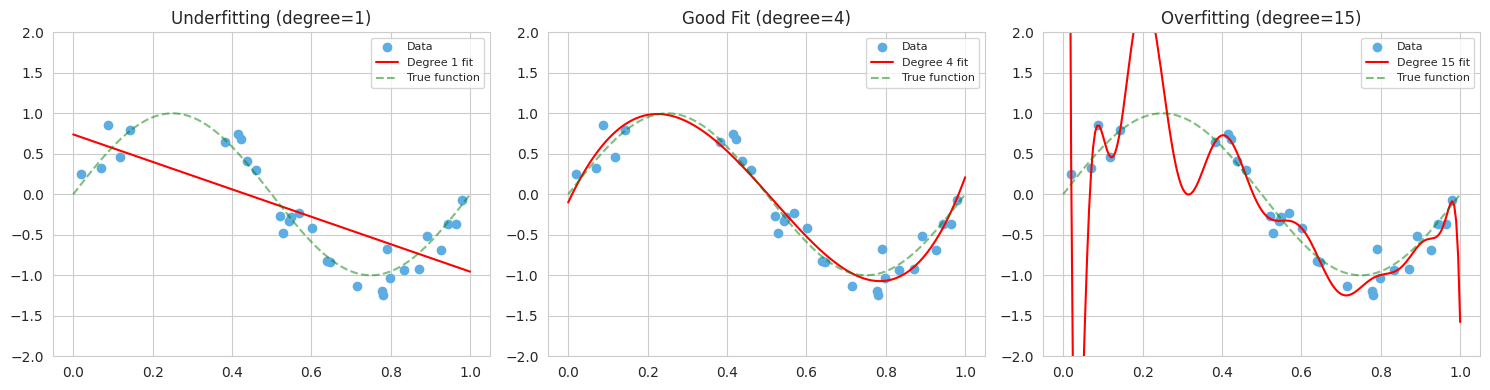

In [19]:
# Overfitting vs Underfitting demo using Polynomial Regression
np.random.seed(0)
X = np.sort(np.random.uniform(0, 1, 30))
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.15, 30)
X_plot = np.linspace(0, 1, 200)

from numpy.polynomial.polynomial import polyfit, polyval

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
degrees = [1, 4, 15]
titles = ["Underfitting (degree=1)", "Good Fit (degree=4)", "Overfitting (degree=15)"]

for ax, deg, title in zip(axes, degrees, titles):
    coeffs = polyfit(X, y, deg)
    y_plot = polyval(X_plot, coeffs)
    ax.scatter(X, y, color="#5DADE2", label="Data")
    ax.plot(X_plot, y_plot, color="red", label=f"Degree {deg} fit")
    ax.plot(X_plot, np.sin(2 * np.pi * X_plot), color="green", linestyle="--", alpha=0.5, label="True function")
    ax.set_ylim(-2, 2)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
save_plot(fig, "17_overfit_underfit.png")
plt.show()


<a id="ch18"></a>
## 🔄 18. Cross Validation
---


### 🧠 Simple Explanation
Instead of a single train-test split, cross-validation splits the data into K parts (folds), trains on K-1 folds and tests on the remaining fold, repeating K times. This gives a more reliable measure of model performance.

### 📖 Definition
> Cross Validation is a resampling technique that splits data into K folds and trains/evaluates the model K times, each time using a different fold as the test set, to obtain a robust estimate of model performance.

### 🌍 Real-life Examples
- 5-fold cross-validation on a medical dataset to ensure stable accuracy estimates
- 10-fold CV used in Kaggle competitions for fair model comparison

### ✅ Advantages
- More reliable performance estimate
- Uses all data for both training and testing
- Reduces the risk of a lucky/unlucky split

### ❌ Disadvantages
- More computationally expensive (trains K models)
- Not ideal for very large datasets or time series without modification

### 💼 Use Cases
- Model selection
- Hyperparameter tuning
- Comparing algorithms fairly

### ❓ Important Interview Questions
1. What is K-Fold Cross Validation?
2. What is the difference between K-Fold and Stratified K-Fold?
3. What is Leave-One-Out Cross Validation (LOOCV)?
4. Why shouldn't you do feature scaling before splitting folds (data leakage)?

---


Cross-validation scores for each fold: [0.967 0.967 0.933 0.967 1.   ]
Mean Accuracy: 0.967  | Std Dev: 0.021
✅ Saved: graphs/18_cross_validation.png


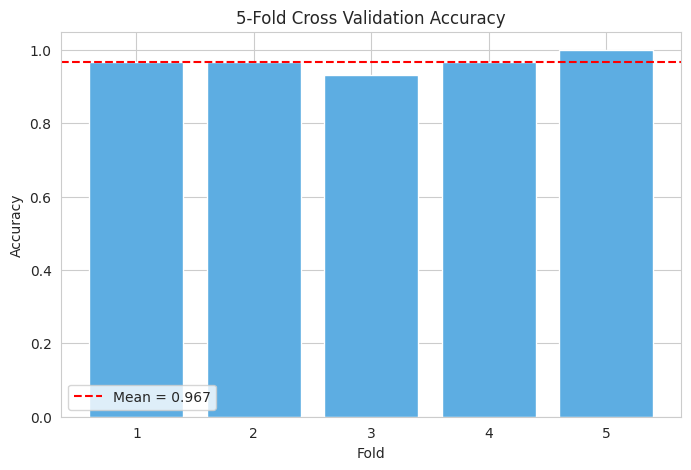

In [20]:
# Cross-validation demo
X = iris.data
y = iris.target

model = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores for each fold:", np.round(cv_scores, 3))
print(f"Mean Accuracy: {cv_scores.mean():.3f}  | Std Dev: {cv_scores.std():.3f}")

fig, ax = plt.subplots()
ax.bar(range(1, 6), cv_scores, color="#5DADE2")
ax.axhline(cv_scores.mean(), color="red", linestyle="--", label=f"Mean = {cv_scores.mean():.3f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("5-Fold Cross Validation Accuracy")
ax.legend()
save_plot(fig, "18_cross_validation.png")
plt.show()


<a id="ch19"></a>
## 🎛️ 19. Hyperparameter Tuning
---


### 🧠 Simple Explanation
Hyperparameters are settings you choose before training (like the number of trees or K value) — they aren't learned from data. Hyperparameter tuning means searching for the best combination of these settings to maximize performance.

### 📖 Definition
> Hyperparameter Tuning is the process of systematically searching for the optimal configuration of a model's hyperparameters using techniques like Grid Search, Random Search, or Bayesian Optimization.

### 🌍 Real-life Examples
- Finding the best 'K' for KNN
- Finding the best max_depth and n_estimators for Random Forest
- Tuning learning rate for a neural network

### ✅ Advantages
- Significantly improves model performance
- Helps avoid overfitting/underfitting via regularization parameters

### ❌ Disadvantages
- Computationally expensive, especially Grid Search
- Risk of overfitting to validation set if not careful

### 💼 Use Cases
- Used in nearly every serious ML project before deployment

### ❓ Important Interview Questions
1. What is the difference between a parameter and a hyperparameter?
2. What is the difference between Grid Search and Random Search?
3. What is Bayesian Optimization for hyperparameter tuning?
4. How do you avoid overfitting during hyperparameter tuning?

---


Best Parameters: {'max_depth': 2, 'n_estimators': 100}
Best CV Accuracy: 0.950
Test Accuracy with best model: 0.900
✅ Saved: graphs/19_gridsearch_heatmap.png


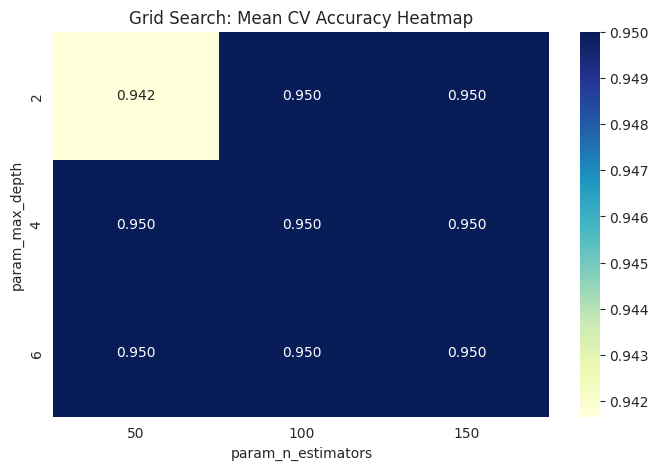

In [21]:
# GridSearchCV demo
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [2, 4, 6, None]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print(f"Best CV Accuracy: {grid.best_score_:.3f}")
print(f"Test Accuracy with best model: {accuracy_score(y_test, grid.best_estimator_.predict(X_test)):.3f}")

results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(values="mean_test_score", index="param_max_depth", columns="param_n_estimators")

fig, ax = plt.subplots()
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("Grid Search: Mean CV Accuracy Heatmap")
save_plot(fig, "19_gridsearch_heatmap.png")
plt.show()


<a id="ch20"></a>
## 🏗️ 20. End-to-End Machine Learning Project
---


### 🧠 The Standard ML Project Workflow

1. **Define the Problem** — What are we predicting? Classification or Regression?
2. **Collect Data** — Gather data from databases, APIs, files, etc.
3. **Explore Data (EDA)** — Visualize, find patterns, correlations, missing values
4. **Preprocess Data** — Clean, encode, scale, handle missing values
5. **Split Data** — Train/Validation/Test sets
6. **Choose & Train Model(s)** — Try multiple algorithms
7. **Evaluate Model** — Use appropriate metrics
8. **Tune Hyperparameters** — Grid/Random Search + Cross Validation
9. **Finalize & Deploy Model** — Save model, build API/app
10. **Monitor in Production** — Track performance, retrain when needed

---


✅ Saved: graphs/20_e2e_pipeline.png


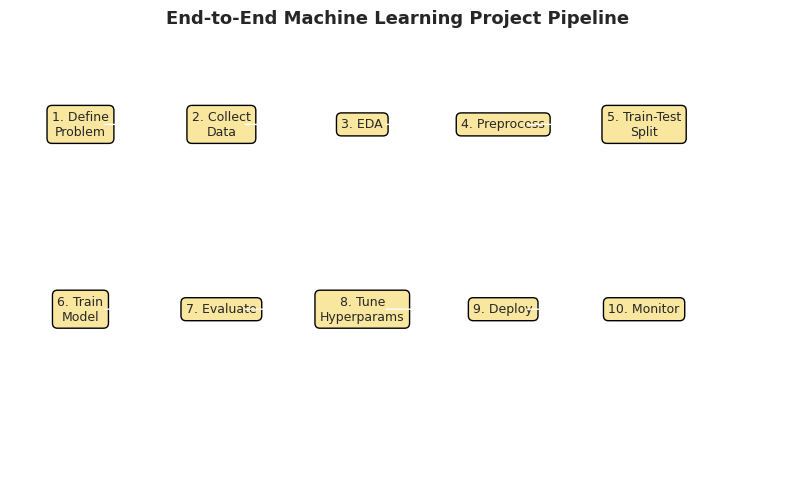

In [22]:
# Full mini end-to-end pipeline summary diagram
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")
steps = ["1. Define\nProblem", "2. Collect\nData", "3. EDA", "4. Preprocess",
         "5. Train-Test\nSplit", "6. Train\nModel", "7. Evaluate", "8. Tune\nHyperparams",
         "9. Deploy", "10. Monitor"]
n = len(steps)
cols = 5
for i, step in enumerate(steps):
    r, c = divmod(i, cols)
    x, y = c * 1.0, 1 - r * 0.6
    ax.text(x, y, step, ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.4", fc="#F9E79F", ec="black"))
    if c < cols - 1:
        ax.annotate("", xy=(x + 0.85, y), xytext=(x + 0.15, y), arrowprops=dict(arrowstyle="->"))
    elif r == 0:
        ax.annotate("", xy=(cols*1.0 - 1.0, y - 0.45), xytext=(x, y - 0.15), arrowprops=dict(arrowstyle="->"))

ax.set_xlim(-0.5, cols)
ax.set_ylim(-0.2, 1.3)
ax.set_title("End-to-End Machine Learning Project Pipeline", fontsize=13, fontweight="bold")
save_plot(fig, "20_e2e_pipeline.png")
plt.show()


<a id="ch21"></a>
## 🚀 21. Mini Projects
---


These mini-projects apply everything learned above to realistic problems. Outputs and trained-model summaries are saved into the `projects/` folder.

---

### 🏠 Project 1: House Price Prediction (Regression)

R2 Score: 0.973
RMSE: 25,735


✅ Saved: graphs/21_house_price_actual_vs_pred.png


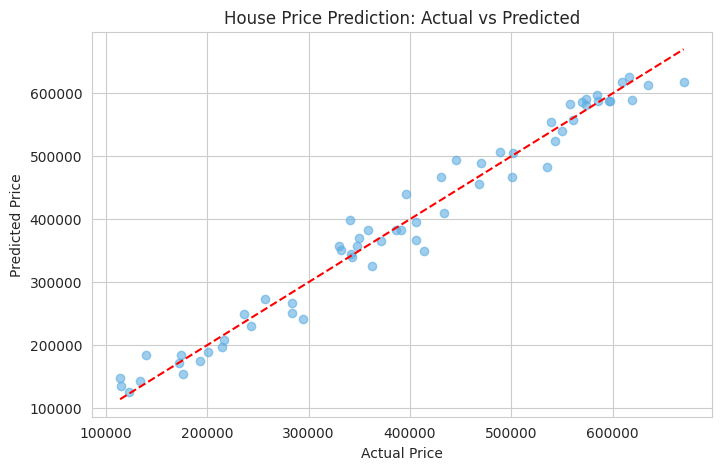

In [23]:
# Project 1: House Price Prediction using synthetic data
np.random.seed(7)
n = 300
area = np.random.uniform(500, 4000, n)
bedrooms = np.random.randint(1, 6, n)
age = np.random.uniform(0, 40, n)
price = (area * 150) + (bedrooms * 20000) - (age * 800) + np.random.normal(0, 25000, n)

house_df = pd.DataFrame({"Area_sqft": area, "Bedrooms": bedrooms, "Age_years": age, "Price": price})
house_df.to_csv(os.path.join(DATASETS_DIR, "house_prices.csv"), index=False)

X = house_df[["Area_sqft", "Bedrooms", "Age_years"]]
y = house_df["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.6, color="#5DADE2")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title("House Price Prediction: Actual vs Predicted")
save_plot(fig, "21_house_price_actual_vs_pred.png")
plt.show()

house_df.describe().to_csv(os.path.join(PROJECTS_DIR, "house_price_summary.csv"))


### 🌸 Project 2: Iris Flower Classification

KNN                    1.000000
Logistic Regression    0.966667
Naive Bayes            0.966667
SVM                    0.966667
Decision Tree          0.933333
Random Forest          0.900000
dtype: float64
✅ Saved: graphs/21_iris_model_comparison.png


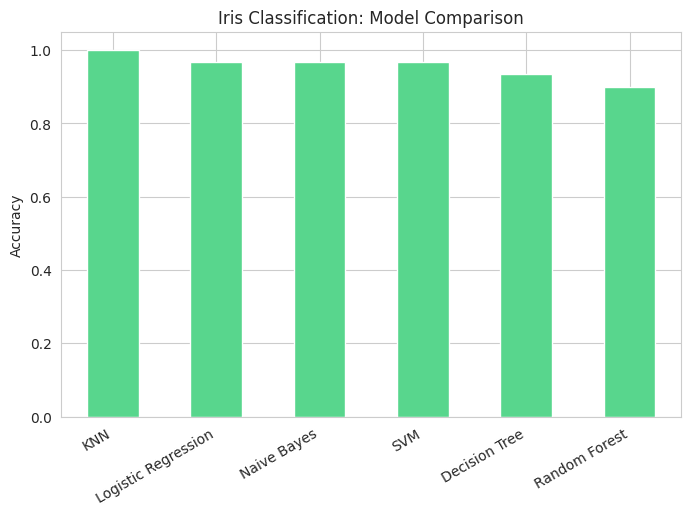

In [24]:
# Project 2: Iris Classification with multiple models compared
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    results[name] = acc

results_df = pd.Series(results).sort_values(ascending=False)
print(results_df)

fig, ax = plt.subplots()
results_df.plot(kind="bar", color="#58D68D", ax=ax)
ax.set_ylabel("Accuracy")
ax.set_title("Iris Classification: Model Comparison")
plt.xticks(rotation=30, ha="right")
save_plot(fig, "21_iris_model_comparison.png")
plt.show()

results_df.to_csv(os.path.join(PROJECTS_DIR, "iris_model_comparison.csv"))


### 🛍️ Project 3: Customer Segmentation (Clustering)

✅ Saved: graphs/21_customer_segmentation.png


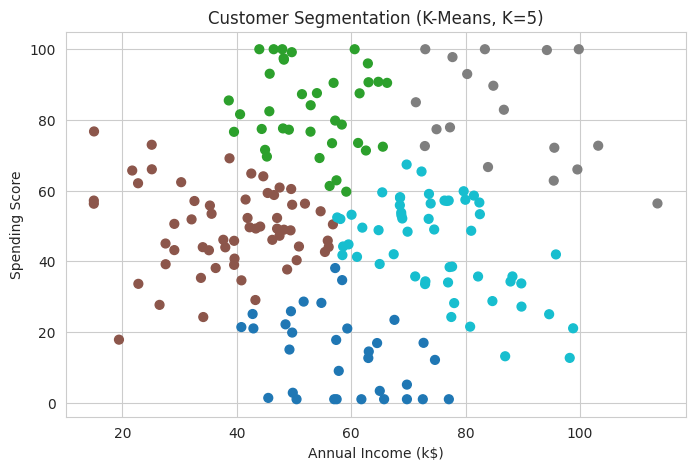

In [25]:
# Project 3: Customer Segmentation using K-Means
np.random.seed(3)
n = 200
annual_income = np.random.normal(60, 20, n).clip(15, 140)
spending_score = np.random.normal(50, 25, n).clip(1, 100)
cust_df = pd.DataFrame({"AnnualIncome_k": annual_income, "SpendingScore": spending_score})
cust_df.to_csv(os.path.join(DATASETS_DIR, "customer_segmentation.csv"), index=False)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cust_df)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cust_df["Cluster"] = kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots()
scatter = ax.scatter(cust_df["AnnualIncome_k"], cust_df["SpendingScore"],
                      c=cust_df["Cluster"], cmap="tab10", s=40)
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score")
ax.set_title("Customer Segmentation (K-Means, K=5)")
save_plot(fig, "21_customer_segmentation.png")
plt.show()

cust_df.to_csv(os.path.join(PROJECTS_DIR, "customer_segments.csv"), index=False)


### 📧 Project 4: Spam Detection (Text Classification)

Spam Detection Accuracy: 0.833


✅ Saved: graphs/21_spam_distribution.png


/tmp/ipykernel_635/2565470721.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=spam_df["label"].map({0: "Not Spam", 1: "Spam"}), ax=ax, palette=["#58D68D", "#E74C3C"])


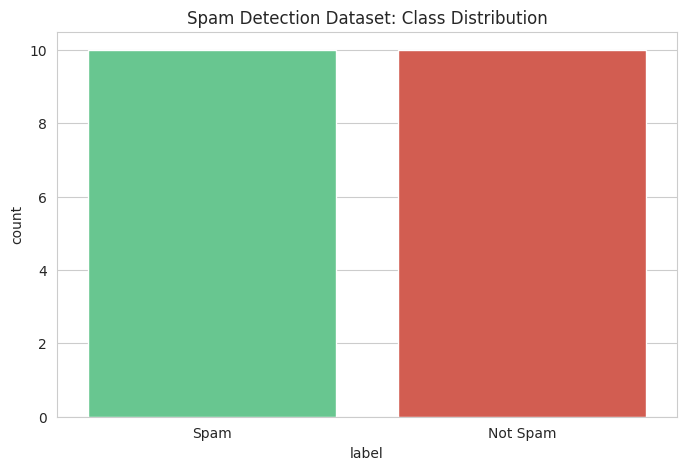

In [26]:
# Project 4: Spam Detection using Naive Bayes on simple bag-of-words features
from sklearn.feature_extraction.text import CountVectorizer

spam_texts = [
    "win money now click here", "free lottery prize claim now", "limited offer buy now discount",
    "congratulations you won a free gift", "urgent your account needs verification",
    "meeting scheduled for tomorrow at 10am", "please review the attached report",
    "let us catch up over lunch this week", "your invoice for last month is attached",
    "can you send me the project file", "free cash prize claim immediately",
    "win a free vacation click link now", "team sync moved to thursday",
    "please find the quarterly summary attached", "exclusive deal just for you act now",
    "reminder your appointment is tomorrow", "earn money fast working from home",
    "your package has been shipped", "important update regarding your account security",
    "lowest price guaranteed buy now"
]
spam_labels = [1,1,1,1,1, 0,0,0,0,0, 1,1,0,0,1, 0,1,0,0,1]

spam_df = pd.DataFrame({"text": spam_texts, "label": spam_labels})
spam_df.to_csv(os.path.join(DATASETS_DIR, "spam_detection.csv"), index=False)

vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(spam_df["text"])
y_text = spam_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X_text, y_text, test_size=0.3, random_state=42)
nb = GaussianNB()
nb.fit(X_train.toarray(), y_train)
y_pred = nb.predict(X_test.toarray())
print(f"Spam Detection Accuracy: {accuracy_score(y_test, y_pred):.3f}")

fig, ax = plt.subplots()
sns.countplot(x=spam_df["label"].map({0: "Not Spam", 1: "Spam"}), ax=ax, palette=["#58D68D", "#E74C3C"])
ax.set_title("Spam Detection Dataset: Class Distribution")
save_plot(fig, "21_spam_distribution.png")
plt.show()


### 🚢 Project 5: Titanic Survival Prediction

Titanic Survival Prediction Accuracy: 0.625


/tmp/ipykernel_635/1081787875.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=titanic_df, ax=ax[0], palette="Blues")
/tmp/ipykernel_635/1081787875.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sex", y="Survived", data=titanic_df, ax=ax[1], palette="Oranges")


✅ Saved: graphs/21_titanic_survival_analysis.png


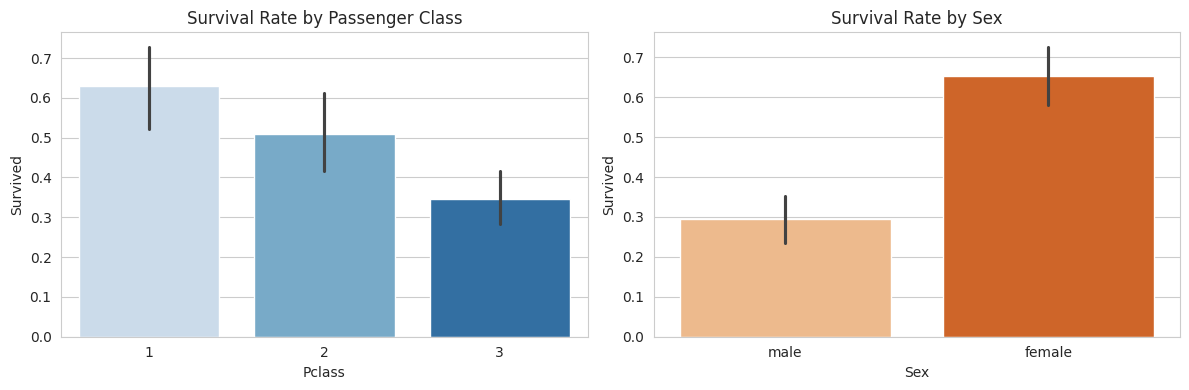

✅ Saved: graphs/21_titanic_correlation_heatmap.png


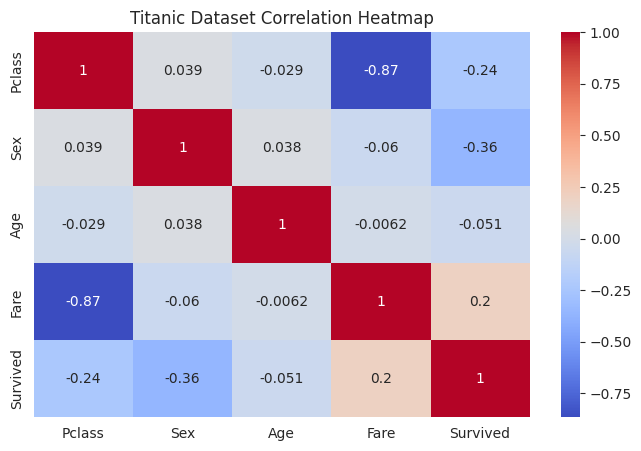

In [27]:
# Project 5: Titanic Survival Prediction using synthetic Titanic-like data
np.random.seed(11)
n = 400
pclass = np.random.choice([1, 2, 3], n, p=[0.25, 0.25, 0.5])
sex = np.random.choice(["male", "female"], n, p=[0.55, 0.45])
age = np.random.normal(30, 12, n).clip(1, 75)
fare = np.where(pclass == 1, np.random.normal(80, 20, n),
        np.where(pclass == 2, np.random.normal(25, 8, n), np.random.normal(12, 5, n))).clip(5, 250)

# survival probability logic (loosely based on real Titanic patterns)
survive_prob = 0.5 + (sex == "female") * 0.35 - (pclass - 1) * 0.12 - (age > 50) * 0.1
survive_prob = np.clip(survive_prob, 0.05, 0.95)
survived = np.random.binomial(1, survive_prob)

titanic_df = pd.DataFrame({"Pclass": pclass, "Sex": sex, "Age": age, "Fare": fare, "Survived": survived})
titanic_df.to_csv(os.path.join(DATASETS_DIR, "titanic.csv"), index=False)

titanic_enc = titanic_df.copy()
titanic_enc["Sex"] = LabelEncoder().fit_transform(titanic_enc["Sex"])

X = titanic_enc[["Pclass", "Sex", "Age", "Fare"]]
y = titanic_enc["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"Titanic Survival Prediction Accuracy: {accuracy_score(y_test, y_pred):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x="Pclass", y="Survived", data=titanic_df, ax=ax[0], palette="Blues")
ax[0].set_title("Survival Rate by Passenger Class")
sns.barplot(x="Sex", y="Survived", data=titanic_df, ax=ax[1], palette="Oranges")
ax[1].set_title("Survival Rate by Sex")
plt.tight_layout()
save_plot(fig, "21_titanic_survival_analysis.png")
plt.show()

# Correlation heatmap
fig, ax = plt.subplots()
sns.heatmap(titanic_enc.corr(), annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Titanic Dataset Correlation Heatmap")
save_plot(fig, "21_titanic_correlation_heatmap.png")
plt.show()


<a id="ch22"></a>
## 📝 22. Revision Notes
---


### 🔑 Quick Revision — Key Takeaways

| Topic | One-Line Summary |
|-------|--------------------|
| Machine Learning | Learning patterns from data instead of hard-coded rules |
| Supervised Learning | Learns from labeled data (input → known output) |
| Unsupervised Learning | Finds hidden structure in unlabeled data |
| Reinforcement Learning | Learns via rewards/penalties from environment interaction |
| Data Preprocessing | Cleaning, encoding, scaling data before modeling |
| Train-Test Split | Separates data to fairly evaluate generalization |
| Linear Regression | Predicts continuous values using a straight-line fit |
| Logistic Regression | Predicts class probabilities using sigmoid function |
| KNN | Classifies based on majority vote of nearest neighbors |
| Decision Tree | Tree of if-else splits based on feature values |
| Random Forest | Ensemble of many decision trees (bagging) |
| SVM | Finds maximum-margin hyperplane between classes |
| Naive Bayes | Probabilistic classifier assuming feature independence |
| K-Means | Groups data into K clusters by minimizing distance to centroids |
| Hierarchical Clustering | Builds nested clusters as a tree (dendrogram) |
| PCA | Reduces dimensions while preserving variance |
| Neural Networks | Layers of neurons learning non-linear patterns |
| Deep Learning | Neural networks with many layers; learns features automatically |
| Evaluation Metrics | Accuracy, Precision, Recall, F1, R², RMSE, ROC-AUC |
| Overfitting | Model too complex, memorizes noise, fails on new data |
| Underfitting | Model too simple, fails to capture patterns |
| Cross Validation | Repeated train/test splits (K-Fold) for robust evaluation |
| Hyperparameter Tuning | Searching best model settings (Grid/Random Search) |

---


<a id="ch23"></a>
## 📋 23. Cheat Sheet
---


### 🐍 Scikit-learn Quick Reference

```python
# Import & Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train any model (same pattern for all!)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Classification metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_score(y_test, y_pred)
classification_report(y_test, y_pred)
confusion_matrix(y_test, y_pred)

# Regression metrics
from sklearn.metrics import mean_squared_error, r2_score
r2_score(y_test, y_pred)

# Cross Validation
from sklearn.model_selection import cross_val_score
cross_val_score(model, X, y, cv=5)

# GridSearch
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X_train, y_train)
```

### ⚡ Algorithm Selection Cheat Sheet

| Problem Type | Try These First |
|---------------|------------------|
| Predicting a number | Linear Regression, Random Forest Regressor |
| Binary classification | Logistic Regression, Random Forest, SVM |
| Multi-class classification | Random Forest, KNN, Naive Bayes |
| No labels / find groups | K-Means, Hierarchical Clustering |
| Too many features | PCA |
| Complex patterns, lots of data | Neural Networks / Deep Learning |

---


<a id="ch24"></a>
## 🧮 24. Formula Sheet
---


### 📐 Important Formulas

**Linear Regression:**
$$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n $$

**Sigmoid Function (Logistic Regression):**
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

**Euclidean Distance (used in KNN, K-Means):**
$$ d(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2} $$

**Entropy (Decision Trees):**
$$ H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i) $$

**Gini Impurity (Decision Trees):**
$$ Gini = 1 - \sum_{i=1}^{c} p_i^2 $$

**Bayes' Theorem (Naive Bayes):**
$$ P(A|B) = \frac{P(B|A) \, P(A)}{P(B)} $$

**Mean Squared Error:**
$$ MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 $$

**R-squared:**
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

**Precision, Recall, F1:**
$$ Precision = \frac{TP}{TP+FP} \quad Recall = \frac{TP}{TP+FN} \quad F1 = \frac{2 \cdot P \cdot R}{P+R} $$

**PCA Variance:** Eigenvectors/eigenvalues of the covariance matrix $\Sigma = \frac{1}{n}X^TX$

---


<a id="ch25"></a>
## 💼 25. Interview Preparation
---


### 🎯 Top Conceptual Interview Questions (with short answers)

1. **What is the bias-variance tradeoff?**
   Bias = error from wrong assumptions (underfitting). Variance = error from sensitivity to training data (overfitting). Good models balance both.

2. **How do you handle imbalanced datasets?**
   Use resampling (SMOTE, undersampling/oversampling), class weights, or metrics like F1/ROC-AUC instead of accuracy.

3. **What is regularization? (L1 vs L2)**
   Regularization adds a penalty to large coefficients to prevent overfitting. L1 (Lasso) can shrink coefficients to zero (feature selection); L2 (Ridge) shrinks them smoothly.

4. **What is the difference between bagging and boosting?**
   Bagging trains models in parallel on random subsets and averages results (e.g., Random Forest). Boosting trains models sequentially, each correcting the previous one's errors (e.g., XGBoost, AdaBoost).

5. **What is feature engineering?**
   Creating new, more useful input features from raw data to improve model performance.

6. **What is the curse of dimensionality?**
   As the number of features grows, data becomes sparse and distance-based algorithms (like KNN) become less effective.

7. **What is data leakage?**
   When information from outside the training set (often from the test set) leaks into model training, causing unrealistically high performance.

8. **How would you explain a complex model to a non-technical stakeholder?**
   Use simple analogies, visualizations (feature importance, decision boundaries), and focus on business impact rather than math.

### 🗂️ Suggested Interview Prep Plan
- Week 1: Math foundations (linear algebra, probability, statistics)
- Week 2: Core algorithms (this notebook!) + hands-on coding
- Week 3: SQL + Data manipulation (Pandas)
- Week 4: System design for ML, case studies, mock interviews

---


<a id="ch26"></a>
## ✅ 26. 100 Machine Learning MCQs with Answers
---


### 📝 100 Machine Learning MCQs

**Q1. What does ML stand for?**

**A.** Machine Language &nbsp;&nbsp; **B.** Machine Learning &nbsp;&nbsp; **C.** Modern Logic &nbsp;&nbsp; **D.** Model Learning

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q2. Which type of learning uses labeled data?**

**A.** Unsupervised &nbsp;&nbsp; **B.** Supervised &nbsp;&nbsp; **C.** Reinforcement &nbsp;&nbsp; **D.** Semi-random

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q3. K-Means is an example of which learning type?**

**A.** Supervised &nbsp;&nbsp; **B.** Unsupervised &nbsp;&nbsp; **C.** Reinforcement &nbsp;&nbsp; **D.** None

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q4. Which algorithm is used for predicting continuous values?**

**A.** Logistic Regression &nbsp;&nbsp; **B.** Linear Regression &nbsp;&nbsp; **C.** KNN Classifier &nbsp;&nbsp; **D.** Naive Bayes

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q5. Sigmoid function output range is:**

**A.** -1 to 1 &nbsp;&nbsp; **B.** 0 to 1 &nbsp;&nbsp; **C.** 0 to infinity &nbsp;&nbsp; **D.** -infinity to infinity

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q6. Which metric is best for imbalanced classification?**

**A.** Accuracy &nbsp;&nbsp; **B.** F1-score &nbsp;&nbsp; **C.** MSE &nbsp;&nbsp; **D.** R2 Score

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q7. What does 'K' represent in KNN?**

**A.** Kernel size &nbsp;&nbsp; **B.** Number of neighbors &nbsp;&nbsp; **C.** Number of clusters &nbsp;&nbsp; **D.** Number of classes

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q8. Which algorithm builds a tree-like model of decisions?**

**A.** SVM &nbsp;&nbsp; **B.** Decision Tree &nbsp;&nbsp; **C.** KNN &nbsp;&nbsp; **D.** PCA

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q9. Random Forest is an ensemble of:**

**A.** Neural Networks &nbsp;&nbsp; **B.** Decision Trees &nbsp;&nbsp; **C.** SVMs &nbsp;&nbsp; **D.** KNNs

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q10. Which technique reduces dimensionality?**

**A.** KNN &nbsp;&nbsp; **B.** PCA &nbsp;&nbsp; **C.** SVM &nbsp;&nbsp; **D.** Naive Bayes

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q11. Naive Bayes is based on:**

**A.** Euclidean distance &nbsp;&nbsp; **B.** Bayes' Theorem &nbsp;&nbsp; **C.** Gradient Descent &nbsp;&nbsp; **D.** Entropy

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q12. Which clustering method produces a dendrogram?**

**A.** K-Means &nbsp;&nbsp; **B.** Hierarchical Clustering &nbsp;&nbsp; **C.** DBSCAN &nbsp;&nbsp; **D.** PCA

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q13. What is overfitting?**

**A.** Model too simple &nbsp;&nbsp; **B.** Model performs well on train but poorly on test &nbsp;&nbsp; **C.** Model has no error &nbsp;&nbsp; **D.** Model underperforms everywhere

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q14. What is underfitting?**

**A.** Model too complex &nbsp;&nbsp; **B.** Model fails to capture patterns &nbsp;&nbsp; **C.** Perfect model &nbsp;&nbsp; **D.** High variance model

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q15. Cross-validation is used for:**

**A.** Data cleaning &nbsp;&nbsp; **B.** Robust performance evaluation &nbsp;&nbsp; **C.** Feature scaling &nbsp;&nbsp; **D.** Visualization

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q16. Grid Search is used for:**

**A.** Data cleaning &nbsp;&nbsp; **B.** Hyperparameter tuning &nbsp;&nbsp; **C.** Feature selection &nbsp;&nbsp; **D.** Clustering

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q17. Which is a hyperparameter in KNN?**

**A.** Weights learned by model &nbsp;&nbsp; **B.** K value &nbsp;&nbsp; **C.** Bias term &nbsp;&nbsp; **D.** Coefficients

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q18. Which scaling method centers data around 0 with unit variance?**

**A.** MinMaxScaler &nbsp;&nbsp; **B.** StandardScaler &nbsp;&nbsp; **C.** LabelEncoder &nbsp;&nbsp; **D.** OneHotEncoder

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q19. One-hot encoding is used for:**

**A.** Numerical scaling &nbsp;&nbsp; **B.** Categorical variables &nbsp;&nbsp; **C.** Missing values &nbsp;&nbsp; **D.** Outlier removal

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q20. Which metric measures average squared error?**

**A.** MAE &nbsp;&nbsp; **B.** MSE &nbsp;&nbsp; **C.** R2 &nbsp;&nbsp; **D.** Accuracy

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q21. Precision formula is:**

**A.** TP/(TP+FN) &nbsp;&nbsp; **B.** TP/(TP+FP) &nbsp;&nbsp; **C.** TN/(TN+FP) &nbsp;&nbsp; **D.** TP/(TP+TN)

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q22. Recall formula is:**

**A.** TP/(TP+FP) &nbsp;&nbsp; **B.** TP/(TP+FN) &nbsp;&nbsp; **C.** TN/(TN+FN) &nbsp;&nbsp; **D.** FP/(FP+TN)

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q23. F1-score is the:**

**A.** Sum of precision and recall &nbsp;&nbsp; **B.** Harmonic mean of precision and recall &nbsp;&nbsp; **C.** Average of accuracy and recall &nbsp;&nbsp; **D.** Product of precision and recall

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q24. ROC curve plots:**

**A.** Precision vs Recall &nbsp;&nbsp; **B.** TPR vs FPR &nbsp;&nbsp; **C.** Accuracy vs Loss &nbsp;&nbsp; **D.** Bias vs Variance

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q25. AUC stands for:**

**A.** Area Under Curve &nbsp;&nbsp; **B.** Average Unit Cost &nbsp;&nbsp; **C.** Algorithm Use Case &nbsp;&nbsp; **D.** Accuracy Under Constraint

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q26. Which algorithm uses entropy or Gini impurity for splitting?**

**A.** KNN &nbsp;&nbsp; **B.** Decision Tree &nbsp;&nbsp; **C.** Linear Regression &nbsp;&nbsp; **D.** K-Means

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q27. Bagging mainly reduces:**

**A.** Bias &nbsp;&nbsp; **B.** Variance &nbsp;&nbsp; **C.** Both equally &nbsp;&nbsp; **D.** Neither

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q28. Boosting mainly reduces:**

**A.** Bias &nbsp;&nbsp; **B.** Variance &nbsp;&nbsp; **C.** Both equally &nbsp;&nbsp; **D.** Neither

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q29. Which is NOT a supervised algorithm?**

**A.** Linear Regression &nbsp;&nbsp; **B.** Decision Tree &nbsp;&nbsp; **C.** K-Means &nbsp;&nbsp; **D.** Logistic Regression

<details><summary>✅ Answer</summary>Answer: <b>C</b></details>

---

**Q30. Which is NOT an unsupervised algorithm?**

**A.** K-Means &nbsp;&nbsp; **B.** PCA &nbsp;&nbsp; **C.** Hierarchical Clustering &nbsp;&nbsp; **D.** Random Forest

<details><summary>✅ Answer</summary>Answer: <b>D</b></details>

---

**Q31. SVM tries to maximize the:**

**A.** Loss &nbsp;&nbsp; **B.** Margin &nbsp;&nbsp; **C.** Bias &nbsp;&nbsp; **D.** Variance

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q32. Kernel trick is used in:**

**A.** Decision Tree &nbsp;&nbsp; **B.** SVM &nbsp;&nbsp; **C.** KNN &nbsp;&nbsp; **D.** Naive Bayes

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q33. Which algorithm is sensitive to feature scaling?**

**A.** Decision Tree &nbsp;&nbsp; **B.** Random Forest &nbsp;&nbsp; **C.** KNN &nbsp;&nbsp; **D.** Naive Bayes

<details><summary>✅ Answer</summary>Answer: <b>C</b></details>

---

**Q34. Which algorithm does NOT require feature scaling?**

**A.** KNN &nbsp;&nbsp; **B.** SVM &nbsp;&nbsp; **C.** Decision Tree &nbsp;&nbsp; **D.** Logistic Regression

<details><summary>✅ Answer</summary>Answer: <b>C</b></details>

---

**Q35. PCA aims to maximize:**

**A.** Bias &nbsp;&nbsp; **B.** Variance explained &nbsp;&nbsp; **C.** Error &nbsp;&nbsp; **D.** Overfitting

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q36. Elbow method is used to find optimal:**

**A.** Learning rate &nbsp;&nbsp; **B.** Number of clusters (K) &nbsp;&nbsp; **C.** Number of neighbors &nbsp;&nbsp; **D.** Number of trees

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q37. Silhouette score measures:**

**A.** Cluster quality &nbsp;&nbsp; **B.** Regression accuracy &nbsp;&nbsp; **C.** Classification accuracy &nbsp;&nbsp; **D.** Feature importance

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q38. Which is a deep learning framework?**

**A.** Scikit-learn &nbsp;&nbsp; **B.** TensorFlow &nbsp;&nbsp; **C.** Pandas &nbsp;&nbsp; **D.** Matplotlib

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q39. CNNs are mainly used for:**

**A.** Tabular data &nbsp;&nbsp; **B.** Image data &nbsp;&nbsp; **C.** Text translation only &nbsp;&nbsp; **D.** Clustering

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q40. RNNs are mainly used for:**

**A.** Image data &nbsp;&nbsp; **B.** Sequential/text data &nbsp;&nbsp; **C.** Clustering &nbsp;&nbsp; **D.** Dimensionality reduction

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q41. Activation function ReLU stands for:**

**A.** Rectified Linear Unit &nbsp;&nbsp; **B.** Random Linear Unit &nbsp;&nbsp; **C.** Regulated Logic Unit &nbsp;&nbsp; **D.** Recursive Linear Unit

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q42. Backpropagation is used to:**

**A.** Initialize weights &nbsp;&nbsp; **B.** Update weights via gradients &nbsp;&nbsp; **C.** Normalize data &nbsp;&nbsp; **D.** Split data

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q43. Vanishing gradient problem occurs mostly in:**

**A.** Shallow networks &nbsp;&nbsp; **B.** Deep networks &nbsp;&nbsp; **C.** Decision Trees &nbsp;&nbsp; **D.** KNN

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q44. Dropout is a technique to prevent:**

**A.** Underfitting &nbsp;&nbsp; **B.** Overfitting &nbsp;&nbsp; **C.** Data leakage &nbsp;&nbsp; **D.** Bias

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q45. Learning rate controls:**

**A.** Number of layers &nbsp;&nbsp; **B.** Step size during optimization &nbsp;&nbsp; **C.** Number of neurons &nbsp;&nbsp; **D.** Activation type

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q46. Gradient Descent is used to:**

**A.** Encode categorical data &nbsp;&nbsp; **B.** Minimize the loss function &nbsp;&nbsp; **C.** Scale features &nbsp;&nbsp; **D.** Split data

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q47. Epoch refers to:**

**A.** One forward pass only &nbsp;&nbsp; **B.** One full pass through training data &nbsp;&nbsp; **C.** One neuron update &nbsp;&nbsp; **D.** One batch only

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q48. Batch size refers to:**

**A.** Number of epochs &nbsp;&nbsp; **B.** Number of samples per gradient update &nbsp;&nbsp; **C.** Number of layers &nbsp;&nbsp; **D.** Number of features

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q49. Which is a regression evaluation metric?**

**A.** Precision &nbsp;&nbsp; **B.** RMSE &nbsp;&nbsp; **C.** F1-score &nbsp;&nbsp; **D.** Confusion Matrix

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q50. Which is a classification evaluation metric?**

**A.** RMSE &nbsp;&nbsp; **B.** MAE &nbsp;&nbsp; **C.** Confusion Matrix &nbsp;&nbsp; **D.** R2 Score

<details><summary>✅ Answer</summary>Answer: <b>C</b></details>

---

**Q51. R2 score of 1 means:**

**A.** Worst possible fit &nbsp;&nbsp; **B.** Perfect fit &nbsp;&nbsp; **C.** No correlation &nbsp;&nbsp; **D.** Overfit model

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q52. A confusion matrix is used to evaluate:**

**A.** Regression models &nbsp;&nbsp; **B.** Classification models &nbsp;&nbsp; **C.** Clustering models &nbsp;&nbsp; **D.** Dimensionality reduction

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q53. True Positive means:**

**A.** Model correctly predicted positive class &nbsp;&nbsp; **B.** Model incorrectly predicted positive &nbsp;&nbsp; **C.** Model correctly predicted negative &nbsp;&nbsp; **D.** Model missed positive class

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q54. False Negative means:**

**A.** Actual negative predicted positive &nbsp;&nbsp; **B.** Actual positive predicted negative &nbsp;&nbsp; **C.** Actual positive predicted positive &nbsp;&nbsp; **D.** Actual negative predicted negative

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q55. Stratified sampling ensures:**

**A.** Random shuffling only &nbsp;&nbsp; **B.** Class proportions are maintained in splits &nbsp;&nbsp; **C.** Faster training &nbsp;&nbsp; **D.** No missing values

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q56. Data leakage leads to:**

**A.** Lower training accuracy &nbsp;&nbsp; **B.** Unrealistically high performance estimates &nbsp;&nbsp; **C.** Slower training &nbsp;&nbsp; **D.** Better generalization

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q57. Label Encoding converts categories into:**

**A.** One-hot vectors &nbsp;&nbsp; **B.** Integer labels &nbsp;&nbsp; **C.** Probabilities &nbsp;&nbsp; **D.** Scaled values

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q58. MinMaxScaler scales data to range:**

**A.** -1 to 1 &nbsp;&nbsp; **B.** 0 to 1 &nbsp;&nbsp; **C.** Mean 0, std 1 &nbsp;&nbsp; **D.** Unbounded

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q59. Which algorithm can handle both regression and classification?**

**A.** K-Means &nbsp;&nbsp; **B.** Decision Tree &nbsp;&nbsp; **C.** PCA &nbsp;&nbsp; **D.** Hierarchical Clustering

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q60. Ensemble learning combines:**

**A.** Multiple datasets only &nbsp;&nbsp; **B.** Multiple models to improve performance &nbsp;&nbsp; **C.** Multiple metrics &nbsp;&nbsp; **D.** Multiple scalers

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q61. AdaBoost is an example of:**

**A.** Bagging &nbsp;&nbsp; **B.** Boosting &nbsp;&nbsp; **C.** Stacking &nbsp;&nbsp; **D.** Clustering

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q62. XGBoost is known for:**

**A.** Slow but accurate boosting &nbsp;&nbsp; **B.** Fast, regularized gradient boosting &nbsp;&nbsp; **C.** Unsupervised clustering &nbsp;&nbsp; **D.** Pure linear modeling

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q63. Which is true about Random Forest vs Decision Tree?**

**A.** Random Forest overfits more &nbsp;&nbsp; **B.** Random Forest generally overfits less &nbsp;&nbsp; **C.** They are identical &nbsp;&nbsp; **D.** Decision Tree is always more accurate

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q64. Which method helps deal with missing values?**

**A.** One-hot encoding &nbsp;&nbsp; **B.** Imputation &nbsp;&nbsp; **C.** PCA &nbsp;&nbsp; **D.** Cross-validation

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q65. Outliers most affect which algorithm?**

**A.** Decision Tree &nbsp;&nbsp; **B.** Linear Regression &nbsp;&nbsp; **C.** Random Forest &nbsp;&nbsp; **D.** KNN with large K

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q66. Which technique converts text into numeric features?**

**A.** StandardScaler &nbsp;&nbsp; **B.** CountVectorizer/TF-IDF &nbsp;&nbsp; **C.** LabelEncoder &nbsp;&nbsp; **D.** PCA

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q67. TF-IDF stands for:**

**A.** Term Frequency-Inverse Document Frequency &nbsp;&nbsp; **B.** Total Frequency in Data Form &nbsp;&nbsp; **C.** Text Format Indexing Function &nbsp;&nbsp; **D.** Term Format Indexed Frame

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q68. Which algorithm assumes feature independence?**

**A.** Decision Tree &nbsp;&nbsp; **B.** Naive Bayes &nbsp;&nbsp; **C.** Random Forest &nbsp;&nbsp; **D.** SVM

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q69. Logistic Regression's decision boundary is typically:**

**A.** Always non-linear &nbsp;&nbsp; **B.** Linear (in basic form) &nbsp;&nbsp; **C.** Random &nbsp;&nbsp; **D.** Undefined

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q70. Which is true about K-Means?**

**A.** Works only with labeled data &nbsp;&nbsp; **B.** Sensitive to initial centroid placement &nbsp;&nbsp; **C.** Always finds global optimum &nbsp;&nbsp; **D.** Doesn't require specifying K

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q71. Hierarchical clustering does NOT require:**

**A.** A distance metric &nbsp;&nbsp; **B.** Pre-specifying number of clusters upfront &nbsp;&nbsp; **C.** A dendrogram &nbsp;&nbsp; **D.** Linkage method

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q72. Which linkage methods exist in hierarchical clustering?**

**A.** Single, Complete, Average, Ward &nbsp;&nbsp; **B.** Only Euclidean &nbsp;&nbsp; **C.** Only Manhattan &nbsp;&nbsp; **D.** None

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q73. L1 regularization is also called:**

**A.** Ridge &nbsp;&nbsp; **B.** Lasso &nbsp;&nbsp; **C.** ElasticNet &nbsp;&nbsp; **D.** Dropout

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q74. L2 regularization is also called:**

**A.** Lasso &nbsp;&nbsp; **B.** Ridge &nbsp;&nbsp; **C.** Dropout &nbsp;&nbsp; **D.** Pooling

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q75. Which can perform automatic feature selection via coefficient shrinkage to zero?**

**A.** Ridge &nbsp;&nbsp; **B.** Lasso &nbsp;&nbsp; **C.** KNN &nbsp;&nbsp; **D.** PCA

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q76. Time series cross-validation differs because:**

**A.** It shuffles data randomly &nbsp;&nbsp; **B.** It preserves temporal order in splits &nbsp;&nbsp; **C.** It doesn't use folds &nbsp;&nbsp; **D.** It requires labeled clusters

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q77. Which is an example of a Reinforcement Learning component?**

**A.** Feature/Label &nbsp;&nbsp; **B.** Agent/Environment/Reward &nbsp;&nbsp; **C.** Centroid/Cluster &nbsp;&nbsp; **D.** Kernel/Margin

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q78. Q-Learning is a type of:**

**A.** Supervised learning &nbsp;&nbsp; **B.** Unsupervised learning &nbsp;&nbsp; **C.** Reinforcement learning &nbsp;&nbsp; **D.** Dimensionality reduction

<details><summary>✅ Answer</summary>Answer: <b>C</b></details>

---

**Q79. Transfer learning means:**

**A.** Training from scratch every time &nbsp;&nbsp; **B.** Reusing a pre-trained model for a new task &nbsp;&nbsp; **C.** Transferring data between databases &nbsp;&nbsp; **D.** Encoding categorical variables

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q80. Which is a common activation function besides ReLU?**

**A.** Sigmoid &nbsp;&nbsp; **B.** StandardScaler &nbsp;&nbsp; **C.** GridSearch &nbsp;&nbsp; **D.** KFold

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q81. Softmax activation is typically used in:**

**A.** Binary regression output &nbsp;&nbsp; **B.** Multi-class classification output layer &nbsp;&nbsp; **C.** Hidden layers only &nbsp;&nbsp; **D.** Clustering

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q82. Which library is commonly used for plotting in Python ML projects?**

**A.** NumPy &nbsp;&nbsp; **B.** Matplotlib/Seaborn &nbsp;&nbsp; **C.** Scikit-learn only &nbsp;&nbsp; **D.** Pandas only

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q83. Pandas is primarily used for:**

**A.** Plotting &nbsp;&nbsp; **B.** Data manipulation and analysis &nbsp;&nbsp; **C.** Deep learning &nbsp;&nbsp; **D.** Web hosting

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q84. NumPy is primarily used for:**

**A.** Numerical computations and arrays &nbsp;&nbsp; **B.** Web scraping &nbsp;&nbsp; **C.** Plotting graphs only &nbsp;&nbsp; **D.** Text processing only

<details><summary>✅ Answer</summary>Answer: <b>A</b></details>

---

**Q85. Which step typically comes first in an ML pipeline?**

**A.** Model deployment &nbsp;&nbsp; **B.** Problem definition and data collection &nbsp;&nbsp; **C.** Hyperparameter tuning &nbsp;&nbsp; **D.** Model evaluation

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q86. Feature scaling is most critical for which algorithm?**

**A.** Decision Tree &nbsp;&nbsp; **B.** SVM &nbsp;&nbsp; **C.** Random Forest &nbsp;&nbsp; **D.** Naive Bayes

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q87. Which evaluation approach is best for small datasets?**

**A.** Single train-test split &nbsp;&nbsp; **B.** K-Fold Cross Validation &nbsp;&nbsp; **C.** No evaluation needed &nbsp;&nbsp; **D.** Only training accuracy

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q88. In GridSearchCV, 'cv' parameter refers to:**

**A.** Number of clusters &nbsp;&nbsp; **B.** Number of cross-validation folds &nbsp;&nbsp; **C.** Number of classes &nbsp;&nbsp; **D.** Convergence value

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q89. Which is a sign of overfitting?**

**A.** Low training and low test accuracy &nbsp;&nbsp; **B.** High training accuracy, low test accuracy &nbsp;&nbsp; **C.** Low training, high test accuracy &nbsp;&nbsp; **D.** Both equally low

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q90. Which is a sign of underfitting?**

**A.** High training and high test accuracy &nbsp;&nbsp; **B.** Low training and low test accuracy &nbsp;&nbsp; **C.** High training, low test accuracy &nbsp;&nbsp; **D.** Perfect scores everywhere

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q91. Early stopping is a regularization technique used in:**

**A.** Decision Trees only &nbsp;&nbsp; **B.** Neural Network training &nbsp;&nbsp; **C.** K-Means &nbsp;&nbsp; **D.** PCA

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q92. Which metric is used to measure clustering quality without ground truth?**

**A.** Accuracy &nbsp;&nbsp; **B.** Silhouette Score &nbsp;&nbsp; **C.** F1-score &nbsp;&nbsp; **D.** RMSE

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q93. A Decision Tree's leaf node represents:**

**A.** A feature &nbsp;&nbsp; **B.** A final prediction/class &nbsp;&nbsp; **C.** A split rule &nbsp;&nbsp; **D.** A hyperparameter

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q94. Which is true about ensemble bagging vs boosting?**

**A.** Bagging is sequential, boosting is parallel &nbsp;&nbsp; **B.** Bagging is parallel, boosting is sequential &nbsp;&nbsp; **C.** Both are always parallel &nbsp;&nbsp; **D.** Both are always sequential

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q95. Which is an example of a parametric model?**

**A.** KNN &nbsp;&nbsp; **B.** Linear Regression &nbsp;&nbsp; **C.** Decision Tree &nbsp;&nbsp; **D.** K-Means

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q96. Which is an example of a non-parametric model?**

**A.** Linear Regression &nbsp;&nbsp; **B.** Logistic Regression &nbsp;&nbsp; **C.** KNN &nbsp;&nbsp; **D.** Naive Bayes

<details><summary>✅ Answer</summary>Answer: <b>C</b></details>

---

**Q97. What is the main goal of model deployment?**

**A.** Train more models &nbsp;&nbsp; **B.** Make the trained model available for real-world predictions &nbsp;&nbsp; **C.** Delete unused data &nbsp;&nbsp; **D.** Reduce dataset size

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q98. Model monitoring after deployment helps detect:**

**A.** Faster training &nbsp;&nbsp; **B.** Model/data drift over time &nbsp;&nbsp; **C.** Better visualizations &nbsp;&nbsp; **D.** More features

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q99. Which Python function splits data into train/test sets in scikit-learn?**

**A.** split_data() &nbsp;&nbsp; **B.** train_test_split() &nbsp;&nbsp; **C.** data_split() &nbsp;&nbsp; **D.** cross_val_score()

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---

**Q100. Which scikit-learn class is used for Random Forest classification?**

**A.** RandomForestRegressor &nbsp;&nbsp; **B.** RandomForestClassifier &nbsp;&nbsp; **C.** DecisionTreeClassifier &nbsp;&nbsp; **D.** BaggingClassifier

<details><summary>✅ Answer</summary>Answer: <b>B</b></details>

---



## 🎉 Congratulations!

You've completed the **Machine Learning Notes** notebook — covering theory, math, code, visuals, mini-projects, and 100 MCQs.

**Next steps:**
- Re-run each chapter's code cells and experiment with the parameters
- Try the mini-projects on real-world datasets (Kaggle)
- Use the Cheat Sheet and Formula Sheet for quick interview revision

📁 All generated plots are saved in `graphs/`, datasets in `datasets/`, and project outputs in `projects/`.

Happy Learning! 🚀


Made By MUHAMMAD MAWIYA